In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account

PROJECT_ID = "ankit-484307"
DATASET_ID = "Sales360_Analysias"
SERVICE_ACCOUNT = "ankit-484307-ca76b86ab896.json"

credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT
)

client = bigquery.Client(
    credentials=credentials,
    project=PROJECT_ID
)

tables = client.list_tables(f"{PROJECT_ID}.{DATASET_ID}")

table_names = [table.table_id for table in tables]
print(table_names)


['Customer_Master', 'Orders', 'Product_Master', 'Returns', 'Store_Master']


In [2]:
df_1 = dataframes["Customer_Master"]
df_2 = dataframes["Orders"]
df_3 = dataframes["Product_Master"]
df_4 = dataframes["Returns"]
df_5 = dataframes["Store_Master"]

In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account
import pandas as pd

PROJECT_ID = "ankit-484307"
DATASET_ID = "Sales360_Analysias"
SERVICE_ACCOUNT = "ankit-484307-ca76b86ab896.json"

credentials = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT
)

client = bigquery.Client(
    credentials=credentials,
    project=PROJECT_ID
)

dataframes = {}

tables = client.list_tables(f"{PROJECT_ID}.{DATASET_ID}")

for table in tables:
    table_id = f"{PROJECT_ID}.{DATASET_ID}.{table.table_id}"
    query = f"SELECT * FROM `{table_id}`"
    df = client.query(query).result().to_dataframe()
    dataframes[table.table_id] = df

print("Loaded tables:", list(dataframes.keys()))


C:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Loaded tables: ['Customer_Master', 'Orders', 'Product_Master', 'Returns', 'Store_Master']


In [ ]:
# 1. EDA

In [11]:
df_1.head()

,Customer_ID,Customer_Name,Gender,Age,City,State,Customer_Segment,Join_Date
0,C200045,Customer_45,Other,18,Bangalore,TN,Consumer,2021-04-13 00:00:00+00:00
1,C200788,Customer_788,Other,18,Bangalore,MH,Consumer,2021-06-15 00:00:00+00:00
2,C200924,Customer_924,Male,18,Bangalore,MH,Consumer,2023-04-28 00:00:00+00:00
3,C201388,Customer_1388,Female,18,Bangalore,KA,Consumer,2022-08-29 00:00:00+00:00
4,C201858,Customer_1858,Other,18,Bangalore,TS,Consumer,2022-06-09 00:00:00+00:00


In [ ]:
6. Promotion impact. 


In [12]:
df_2.head()

,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,Net_Sales,Profit,Payment_Mode,Order_Status
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,81.07,-1699.96,Credit Card,Completed
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,110.25,-3723.39,Wallet,Completed
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,114.56,-2818.43,Credit Card,Completed
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,123.61,-2913.46,Debit Card,Completed
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,140.70,-3216.95,Credit Card,Completed


In [13]:
df_3.head()

,Product_ID,Product_Name,Category,Brand,Unit_Cost,Unit_Price,Launch_Date,Product_Status
0,P100009,Product_9,Beauty,Alpha,258.36,4086.35,2022-05-04 00:00:00+00:00,Active
1,P100123,Product_123,Beauty,Alpha,3455.03,5845.28,2023-03-15 00:00:00+00:00,Discontinued
2,P100162,Product_162,Beauty,Alpha,3210.70,2140.45,2023-08-30 00:00:00+00:00,Active
3,P100186,Product_186,Beauty,Alpha,3102.42,727.26,2023-02-24 00:00:00+00:00,Active
4,P100311,Product_311,Beauty,Alpha,1273.79,1879.26,2022-12-06 00:00:00+00:00,Active


In [14]:
df_4.head()

,Return_ID,Order_ID,Return_Date,Return_Reason,Net_Sales
0,R500000,O500000,2024-03-19 00:00:00+00:00,Customer Dissatisfied,911.14
1,R500047,O500047,2024-01-16 00:00:00+00:00,Customer Dissatisfied,16581.31
2,R500116,O500116,2024-04-04 00:00:00+00:00,Customer Dissatisfied,16343.32
3,R500137,O500137,2025-06-28 00:00:00+00:00,Customer Dissatisfied,9074.24
4,R500184,O500184,2024-02-16 00:00:00+00:00,Customer Dissatisfied,6225.01


In [15]:
df_5.head()

,Store_ID,Store_Name,Store_Type,City,State,Region,Open_Date
0,S3019,Store_19,Retail,Bangalore,KA,East,2021-08-26 00:00:00+00:00
1,S3092,Store_92,Retail,Bangalore,MH,East,2020-11-07 00:00:00+00:00
2,S3093,Store_93,Retail,Bangalore,KA,East,2021-09-18 00:00:00+00:00
3,S3095,Store_95,Online,Bangalore,KA,East,2022-08-10 00:00:00+00:00
4,S3115,Store_115,Online,Bangalore,KA,East,2021-05-27 00:00:00+00:00


In [ ]:
 5. Customer acquisition & retention

In [16]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   Customer_ID       5000 non-null   object             
 1   Customer_Name     5000 non-null   object             
 2   Gender            5000 non-null   object             
 3   Age               5000 non-null   Int64              
 4   City              5000 non-null   object             
 5   State             5000 non-null   object             
 6   Customer_Segment  5000 non-null   object             
 7   Join_Date         5000 non-null   datetime64[us, UTC]
dtypes: Int64(1), datetime64[us, UTC](1), object(6)
memory usage: 317.5+ KB


In [17]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Order_ID         25000 non-null  object             
 1   Order_Date       25000 non-null  datetime64[us, UTC]
 2   Customer_ID      25000 non-null  object             
 3   Product_ID       25000 non-null  object             
 4   Store_ID         25000 non-null  object             
 5   Quantity         25000 non-null  Int64              
 6   Unit_Price       25000 non-null  float64            
 7   Discount_%       25000 non-null  Int64              
 8   Discount_Amount  25000 non-null  float64            
 9   Gross_Sales      25000 non-null  float64            
 10  Net_Sales        25000 non-null  float64            
 11  Profit           25000 non-null  float64            
 12  Payment_Mode     25000 non-null  object             
 13  Order_Status    

In [18]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   Product_ID      800 non-null    object             
 1   Product_Name    800 non-null    object             
 2   Category        800 non-null    object             
 3   Brand           800 non-null    object             
 4   Unit_Cost       800 non-null    float64            
 5   Unit_Price      800 non-null    float64            
 6   Launch_Date     800 non-null    datetime64[us, UTC]
 7   Product_Status  800 non-null    object             
dtypes: datetime64[us, UTC](1), float64(2), object(5)
memory usage: 50.1+ KB


In [19]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Return_ID      1527 non-null   object             
 1   Order_ID       1527 non-null   object             
 2   Return_Date    1527 non-null   datetime64[us, UTC]
 3   Return_Reason  1527 non-null   object             
 4   Net_Sales      1527 non-null   float64            
dtypes: datetime64[us, UTC](1), float64(1), object(3)
memory usage: 59.8+ KB


In [20]:
df_5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype              
---  ------      --------------  -----              
 0   Store_ID    120 non-null    object             
 1   Store_Name  120 non-null    object             
 2   Store_Type  120 non-null    object             
 3   City        120 non-null    object             
 4   State       120 non-null    object             
 5   Region      120 non-null    object             
 6   Open_Date   120 non-null    datetime64[us, UTC]
dtypes: datetime64[us, UTC](1), object(6)
memory usage: 6.7+ KB


In [21]:
df_1.isnull().sum()

Customer_ID         0
Customer_Name       0
Gender              0
Age                 0
City                0
State               0
Customer_Segment    0
Join_Date           0
dtype: int64

In [22]:
df_2.isnull().sum()


Order_ID           0
Order_Date         0
Customer_ID        0
Product_ID         0
Store_ID           0
Quantity           0
Unit_Price         0
Discount_%         0
Discount_Amount    0
Gross_Sales        0
Net_Sales          0
Profit             0
Payment_Mode       0
Order_Status       0
dtype: int64

In [23]:
df_3.isnull().sum()


Product_ID        0
Product_Name      0
Category          0
Brand             0
Unit_Cost         0
Unit_Price        0
Launch_Date       0
Product_Status    0
dtype: int64

In [24]:
df_4.isnull().sum()


Return_ID        0
Order_ID         0
Return_Date      0
Return_Reason    0
Net_Sales        0
dtype: int64

In [25]:
df_5.isnull().sum()


Store_ID      0
Store_Name    0
Store_Type    0
City          0
State         0
Region        0
Open_Date     0
dtype: int64

In [26]:
df_1.duplicated().sum()

np.int64(0)

In [27]:
df_2.duplicated().sum()

np.int64(0)

In [28]:
df_3.duplicated().sum()

np.int64(0)

In [29]:
df_4.duplicated().sum()

np.int64(0)

In [30]:
df_5.duplicated().sum()

np.int64(0)

In [32]:
df_1['State'].unique()

array(['TN', 'MH', 'KA', 'TS', 'Delhi'], dtype=object)

In [33]:
df_1['Age'].describe()


count       5000.0
mean       40.7508
std      13.462383
min           18.0
25%           30.0
50%           40.0
75%           52.0
max           64.0
Name: Age, dtype: Float64

In [50]:
df_1.describe()

,Age
count,5000.0
mean,40.7508
std,13.462383
min,18.0
25%,30.0
50%,40.0
75%,52.0
max,64.0


In [35]:
df_2.describe()

,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,Net_Sales,Profit
count,25000.0,25000.000000,25000.0,25000.000000,25000.000000,25000.000000,25000.000000
mean,2.99976,4022.385190,9.958,1202.051568,12071.249642,10869.198122,3255.914251
std,1.411977,2266.115008,7.065991,1425.275120,9409.767347,8541.194713,8473.643635
min,1.0,81.070000,0.0,0.000000,81.070000,64.860000,-23956.140000
25%,2.0,2152.710000,5.0,107.750000,4512.887500,4013.755000,-1604.632500
50%,3.0,4022.680000,10.0,703.490000,9653.560000,8599.300000,2280.330000
75%,4.0,5969.260000,15.0,1748.260000,17920.297500,16055.320000,7551.000000
max,5.0,7986.910000,20.0,7986.910000,39934.550000,39934.550000,37870.850000


In [51]:
df_3.describe()

,Unit_Cost,Unit_Price
count,800.000000,800.000000
mean,2541.742975,4037.593375
std,1447.581061,2269.662226
min,74.450000,81.070000
25%,1225.007500,2219.515000
50%,2586.655000,4054.680000
75%,3789.695000,5991.975000
max,4997.100000,7986.910000


In [52]:
df_4.describe()

,Net_Sales
count,1527.000000
mean,11218.433451
std,8729.795835
min,87.780000
25%,4262.990000
50%,9109.940000
75%,16565.090000
max,38655.500000


In [53]:
df_5.describe()

,Store_ID,Store_Name,Store_Type,City,State,Region,Open_Date
count,120,120,120,120,120,120,120
unique,120,120,2,6,5,4,NaN
top,S3019,Store_19,Retail,Chennai,KA,South,NaN
freq,1,1,64,27,28,33,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-04 23:48:00+00:00
min,NaN,NaN,NaN,NaN,NaN,NaN,2019-12-30 00:00:00+00:00
25%,NaN,NaN,NaN,NaN,NaN,NaN,2021-03-27 06:00:00+00:00
50%,NaN,NaN,NaN,NaN,NaN,NaN,2022-01-24 00:00:00+00:00
75%,NaN,NaN,NaN,NaN,NaN,NaN,2022-12-02 12:00:00+00:00
max,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-04 00:00:00+00:00


In [78]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Order_ID         25000 non-null  object             
 1   Order_Date       25000 non-null  datetime64[us, UTC]
 2   Customer_ID      25000 non-null  object             
 3   Product_ID       25000 non-null  object             
 4   Store_ID         25000 non-null  object             
 5   Quantity         25000 non-null  Int64              
 6   Unit_Price       25000 non-null  float64            
 7   Discount_%       25000 non-null  Int64              
 8   Discount_Amount  25000 non-null  float64            
 9   Gross_Sales      25000 non-null  float64            
 10  Net_Sales        25000 non-null  float64            
 11  Profit           25000 non-null  float64            
 12  Payment_Mode     25000 non-null  object             
 13  Order_Status    

In [ ]:
# 6.  Business Requirements 


In [ ]:
# 1. Track sales trends. 


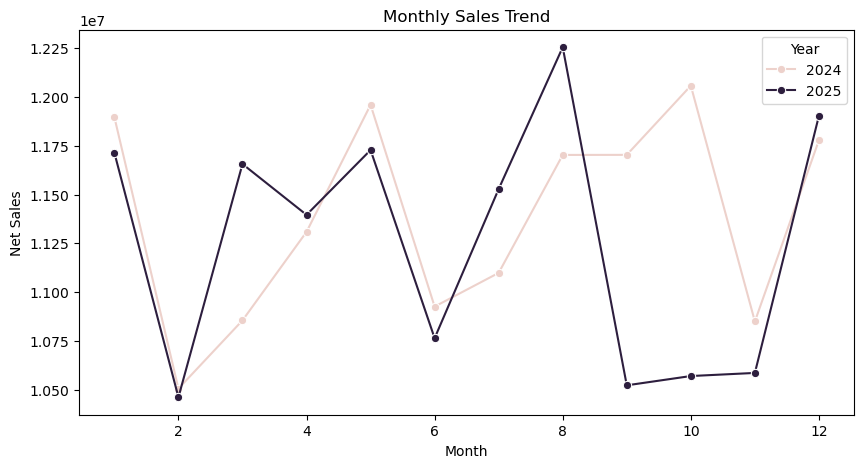

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Net_Sales',
    hue='Year',
    marker='o'
)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Net Sales')
plt.show()


In [ ]:
# 2. Product revenue & margin. 

In [86]:
product_perf = (
    df_2
    .groupby('Product_ID', as_index=False)
    .agg(
        Revenue=('Net_Sales', 'sum'),
        Profit=('Profit', 'sum')
    )
)


In [88]:
product_perf.head()


,Product_ID,Revenue,Profit
0,P100000,497036.80,232293.05
1,P100001,769737.26,539079.50
2,P100002,554178.54,250694.08
3,P100003,38987.28,-85439.66
4,P100004,106670.37,56534.97


In [89]:
product_perf['Margin_%'] = (
    product_perf['Profit'] / product_perf['Revenue']
) * 100


In [90]:
top_products_revenue = product_perf.sort_values(
    by='Revenue', ascending=False
).head(10)

top_products_revenue


,Product_ID,Revenue,Profit,Margin_%
569,P100569,905438.70,487774.93,53.871668
690,P100690,882595.03,720881.53,81.677497
508,P100508,848843.01,724527.54,85.354716
640,P100640,845533.84,533775.04,63.128761
666,P100666,828209.27,472245.17,57.020029
355,P100355,826129.63,528638.93,63.989828
635,P100635,816920.57,258099.86,31.594242
652,P100652,815493.64,213568.22,26.188827
237,P100237,811521.72,786140.67,96.872413
337,P100337,810546.14,707953.52,87.342779


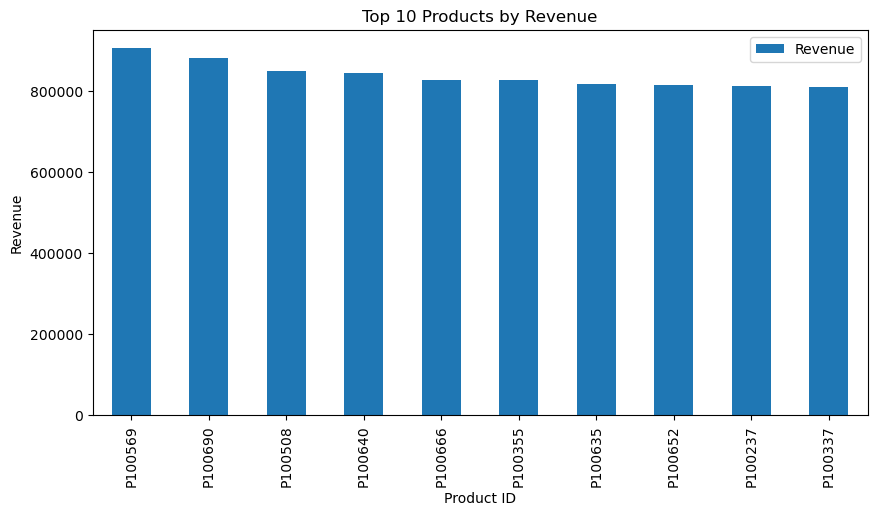

In [91]:
top_products_revenue.plot(
    x='Product_ID', y='Revenue', kind='bar', figsize=(10,5)
)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product ID')
plt.ylabel('Revenue')
plt.show()


In [92]:
low_margin_products = product_perf.sort_values(
    by='Margin_%'
).head(10)

low_margin_products


,Product_ID,Revenue,Profit,Margin_%
58,P100058,9351.68,-454353.91,-4858.527131
38,P100038,10624.25,-469234.72,-4416.638539
748,P100748,8577.43,-324949.25,-3788.422056
361,P100361,19686.60,-577305.62,-2932.480063
665,P100665,10919.54,-319491.61,-2925.870595
769,P100769,11249.80,-305513.12,-2715.720457
431,P100431,7212.65,-193233.96,-2679.097974
432,P100432,11642.92,-300618.55,-2581.985876
741,P100741,6761.22,-158874.56,-2349.791310
486,P100486,14798.19,-313164.11,-2116.232526


In [ ]:
# 3. Top/Bottom SKUs. 


In [93]:
sku_perf = (
    df_2
    .groupby('Product_ID', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [94]:
sku_perf.head()


,Product_ID,Total_Sales,Total_Profit,Units_Sold
0,P100000,497036.80,232293.05,125
1,P100001,769737.26,539079.50,108
2,P100002,554178.54,250694.08,82
3,P100003,38987.28,-85439.66,101
4,P100004,106670.37,56534.97,84


In [95]:
top_skus_sales = sku_perf.sort_values(
    by='Total_Sales', ascending=False
).head(10)

top_skus_sales


,Product_ID,Total_Sales,Total_Profit,Units_Sold
569,P100569,905438.70,487774.93,125
690,P100690,882595.03,720881.53,130
508,P100508,848843.01,724527.54,141
640,P100640,845533.84,533775.04,122
666,P100666,828209.27,472245.17,115
355,P100355,826129.63,528638.93,130
635,P100635,816920.57,258099.86,116
652,P100652,815493.64,213568.22,121
237,P100237,811521.72,786140.67,123
337,P100337,810546.14,707953.52,117


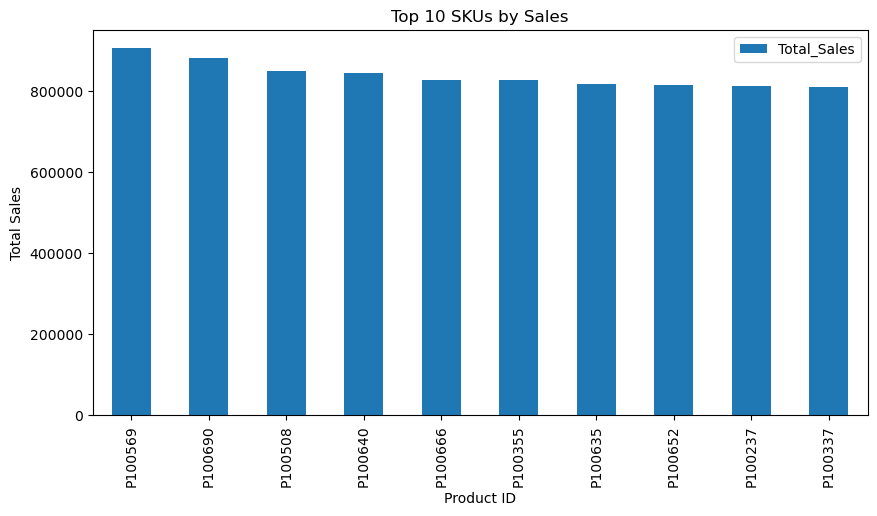

In [96]:
top_skus_sales.plot(
    x='Product_ID', y='Total_Sales',
    kind='bar', figsize=(10,5)
)
plt.title('Top 10 SKUs by Sales')
plt.xlabel('Product ID')
plt.ylabel('Total Sales')
plt.show()


In [97]:
bottom_skus_sales = sku_perf.sort_values(
    by='Total_Sales', ascending=True
).head(10)

bottom_skus_sales


,Product_ID,Total_Sales,Total_Profit,Units_Sold
741,P100741,6761.22,-158874.56,93
464,P100464,7197.96,-127915.78,86
431,P100431,7212.65,-193233.96,66
23,P100023,8357.32,-176826.08,60
748,P100748,8577.43,-324949.25,87
58,P100058,9351.68,-454353.91,97
38,P100038,10624.25,-469234.72,99
665,P100665,10919.54,-319491.61,81
769,P100769,11249.80,-305513.12,108
432,P100432,11642.92,-300618.55,93


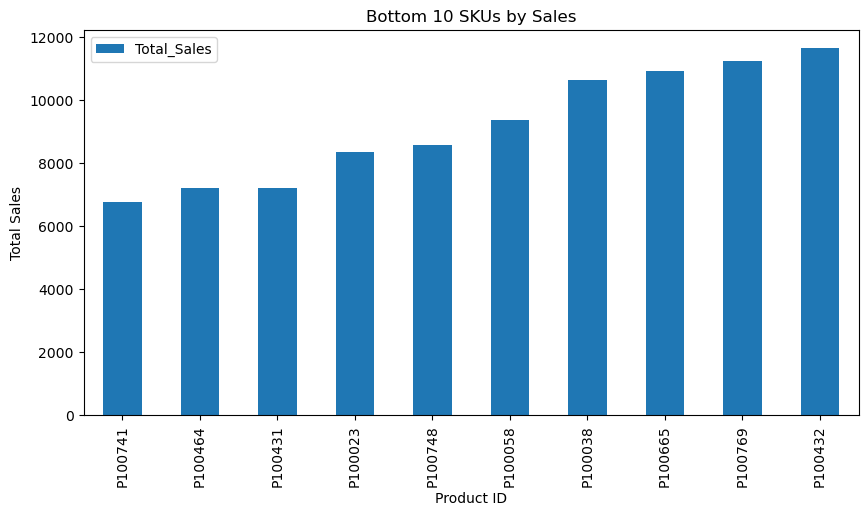

In [98]:
bottom_skus_sales.plot(
    x='Product_ID', y='Total_Sales',
    kind='bar', figsize=(10,5)
)
plt.title('Bottom 10 SKUs by Sales')
plt.xlabel('Product ID')
plt.ylabel('Total Sales')
plt.show()


In [99]:
top_skus_profit = sku_perf.sort_values(
    by='Total_Profit', ascending=False
).head(10)

top_skus_profit


,Product_ID,Total_Sales,Total_Profit,Units_Sold
237,P100237,811521.72,786140.67,123
286,P100286,799423.48,766367.66,133
350,P100350,785186.34,748269.96,111
170,P100170,761882.55,740042.78,107
648,P100648,769274.26,726478.98,121
508,P100508,848843.01,724527.54,141
690,P100690,882595.03,720881.53,130
337,P100337,810546.14,707953.52,117
328,P100328,745386.92,698212.58,114
53,P100053,756363.30,695517.24,121


In [100]:
bottom_skus_profit = sku_perf.sort_values(
    by='Total_Profit', ascending=True
).head(10)

bottom_skus_profit


,Product_ID,Total_Sales,Total_Profit,Units_Sold
361,P100361,19686.60,-577305.62,121
27,P100027,107840.03,-533606.69,136
167,P100167,248328.87,-490176.48,165
38,P100038,10624.25,-469234.72,99
781,P100781,43600.99,-456531.42,106
58,P100058,9351.68,-454353.91,97
790,P100790,52160.84,-452428.89,119
122,P100122,71117.63,-444703.17,110
134,P100134,56823.11,-432617.85,101
356,P100356,95755.12,-422912.36,111


In [ ]:
# 4. Store/Region performance. 


In [101]:
df_store_sales = df_2.merge(
    df_5[['Store_ID', 'Store_Name', 'Store_Type', 'City', 'State', 'Region']],
    on='Store_ID',
    how='left'
)


In [102]:
df_store_sales.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,...,Profit,Payment_Mode,Order_Status,Year,Month,Store_Name,Store_Type,City,State,Region
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,...,-1699.96,Credit Card,Completed,2024,6,Store_96,Online,Pune,MH,South
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,...,-3723.39,Wallet,Completed,2024,10,Store_103,Retail,Mumbai,KA,North
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,...,-2818.43,Credit Card,Completed,2024,4,Store_69,Retail,Bangalore,TS,North
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,...,-2913.46,Debit Card,Completed,2024,12,Store_86,Online,Chennai,MH,West
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,...,-3216.95,Credit Card,Completed,2025,3,Store_51,Retail,Delhi,TS,South


In [103]:
store_perf = (
    df_store_sales
    .groupby(['Store_ID', 'Store_Name', 'Store_Type', 'Region'], as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [104]:
store_perf.head()


,Store_ID,Store_Name,Store_Type,Region,Total_Sales,Total_Profit,Units_Sold
0,S3000,Store_0,Retail,South,2071075.40,567588.49,573
1,S3001,Store_1,Retail,North,2475852.93,734191.78,670
2,S3002,Store_2,Online,South,2144925.36,388281.41,674
3,S3003,Store_3,Retail,North,2346490.60,628762.96,674
4,S3004,Store_4,Online,North,2036826.65,499261.79,582


In [105]:
top_stores_sales = store_perf.sort_values(
    by='Total_Sales', ascending=False
).head(10)

top_stores_sales


,Store_ID,Store_Name,Store_Type,Region,Total_Sales,Total_Profit,Units_Sold
21,S3021,Store_21,Online,North,2706543.71,1107581.97,699
61,S3061,Store_61,Retail,West,2704558.81,785141.10,741
89,S3089,Store_89,Retail,South,2701550.94,1038390.11,674
34,S3034,Store_34,Retail,West,2692652.53,1004877.18,721
82,S3082,Store_82,Retail,West,2657002.32,1142625.23,685
75,S3075,Store_75,Online,South,2642221.84,877045.07,696
67,S3067,Store_67,Retail,South,2642010.21,882913.92,701
60,S3060,Store_60,Online,West,2598203.12,904790.55,695
30,S3030,Store_30,Online,West,2585166.94,894044.89,657
112,S3112,Store_112,Online,North,2585077.45,790388.91,674


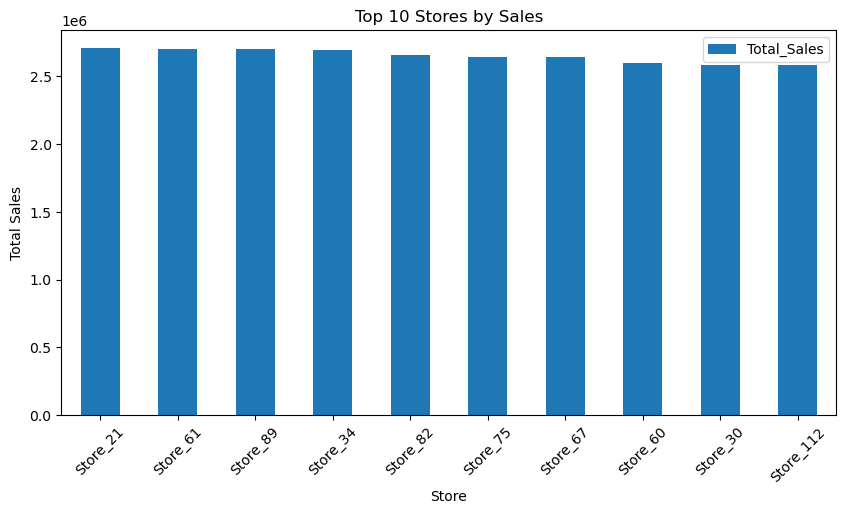

In [106]:
top_stores_sales.plot(
    x='Store_Name', y='Total_Sales',
    kind='bar', figsize=(10,5)
)
plt.title('Top 10 Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [107]:
bottom_stores_sales = store_perf.sort_values(
    by='Total_Sales', ascending=True
).head(10)

bottom_stores_sales


,Store_ID,Store_Name,Store_Type,Region,Total_Sales,Total_Profit,Units_Sold
39,S3039,Store_39,Retail,East,1726572.60,530874.09,515
52,S3052,Store_52,Online,North,1768097.57,393567.08,510
78,S3078,Store_78,Online,West,1823474.35,447495.07,549
79,S3079,Store_79,Retail,North,1848357.05,382933.57,534
64,S3064,Store_64,Retail,South,1906893.11,359330.38,589
68,S3068,Store_68,Retail,East,1926708.75,411559.71,586
27,S3027,Store_27,Retail,West,1936075.68,578360.41,553
48,S3048,Store_48,Retail,North,1938239.30,521925.82,540
83,S3083,Store_83,Online,West,1939968.46,550281.43,548
66,S3066,Store_66,Retail,South,1940180.18,521468.61,581


In [108]:
region_perf = (
    df_store_sales
    .groupby('Region', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [109]:
region_perf


,Region,Total_Sales,Total_Profit,Units_Sold
0,East,62999295.48,19159015.13,17384
1,North,69289435.82,20018264.14,19196
2,South,74921024.74,22421976.37,20657
3,West,64520197.01,19798600.63,17757


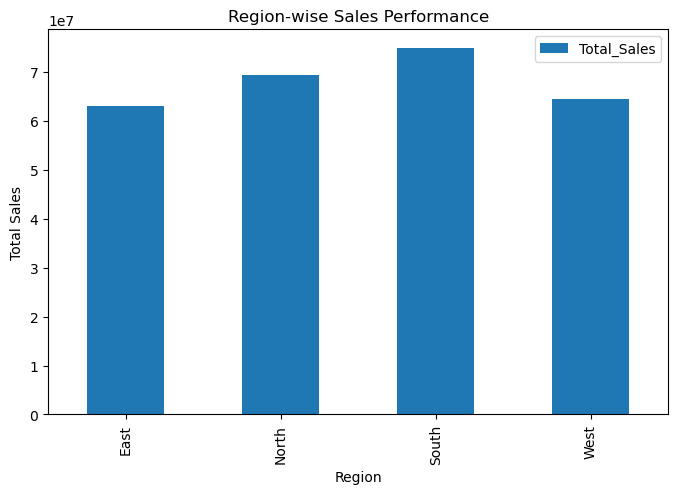

In [110]:
region_perf.plot(
    x='Region', y='Total_Sales',
    kind='bar', figsize=(8,5)
)
plt.title('Region-wise Sales Performance')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
 #  5. Customer acquisition & retention

In [111]:
df_1['Join_Date'] = pd.to_datetime(df_1['Join_Date'])
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [112]:
df_1['Join_Year'] = df_1['Join_Date'].dt.year
df_1['Join_Month'] = df_1['Join_Date'].dt.month


In [113]:
customer_acquisition = (
    df_1
    .groupby(['Join_Year', 'Join_Month'], as_index=False)
    .agg(New_Customers=('Customer_ID', 'nunique'))
    .sort_values(['Join_Year', 'Join_Month'])
)


In [114]:
customer_acquisition


,Join_Year,Join_Month,New_Customers
0,2021,4,110
1,2021,5,144
2,2021,6,169
3,2021,7,174
4,2021,8,153
5,2021,9,169
6,2021,10,157
7,2021,11,156
8,2021,12,157
9,2022,1,169


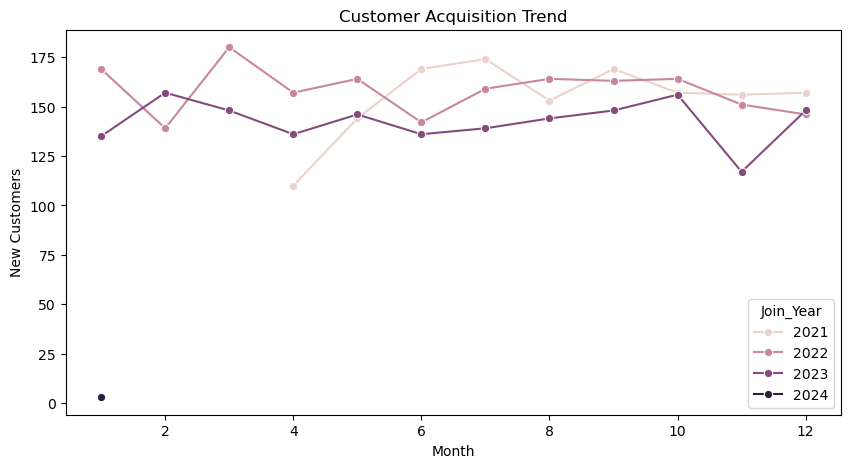

In [115]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=customer_acquisition,
    x='Join_Month',
    y='New_Customers',
    hue='Join_Year',
    marker='o'
)
plt.title('Customer Acquisition Trend')
plt.xlabel('Month')
plt.ylabel('New Customers')
plt.show()


In [116]:
first_purchase = (
    df_2
    .groupby('Customer_ID')['Order_Date']
    .min()
    .reset_index()
    .rename(columns={'Order_Date': 'First_Purchase_Date'})
)


In [117]:
df_customer_orders = df_2.merge(
    first_purchase,
    on='Customer_ID',
    how='left'
)


In [120]:
import numpy as np


In [121]:
df_customer_orders['Customer_Type'] = np.where(
    df_customer_orders['Order_Date'] == df_customer_orders['First_Purchase_Date'],
    'New',
    'Returning'
)


In [122]:
df_customer_orders['Customer_Type'].value_counts()


Customer_Type
Returning    20017
New           4983
Name: count, dtype: int64

In [123]:
customer_type_sales = (
    df_customer_orders
    .groupby('Customer_Type', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Orders=('Order_ID', 'nunique')
    )
)


In [124]:
customer_type_sales


,Customer_Type,Total_Sales,Total_Orders
0,New,5.430693e+07,4983
1,Returning,2.174230e+08,20017


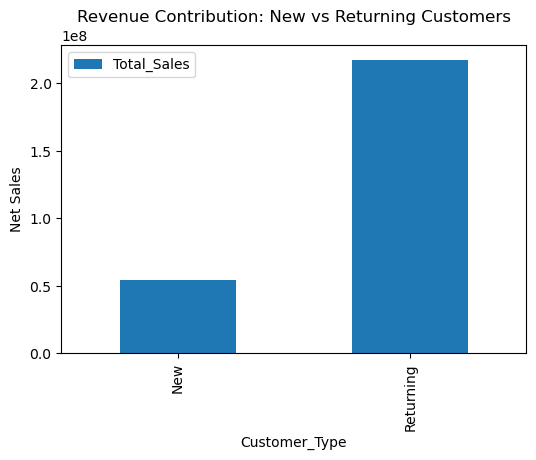

In [125]:
customer_type_sales.plot(
    x='Customer_Type', y='Total_Sales',
    kind='bar', figsize=(6,4)
)
plt.title('Revenue Contribution: New vs Returning Customers')
plt.ylabel('Net Sales')
plt.show()


In [126]:
customer_orders = (
    df_2
    .groupby('Customer_ID')['Order_ID']
    .nunique()
    .reset_index(name='Total_Orders')
)


In [127]:
customer_orders['Total_Orders'].describe()


count    4971.000000
mean        5.029169
std         2.203106
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        15.000000
Name: Total_Orders, dtype: float64

In [128]:
customer_orders['Customer_Category'] = np.where(
    customer_orders['Total_Orders'] > 1,
    'Repeat Customer',
    'One-Time Customer'
)

customer_orders['Customer_Category'].value_counts()


Customer_Category
Repeat Customer      4802
One-Time Customer     169
Name: count, dtype: int64

In [ ]:
# 6. Promotion impact. 


In [96]:
df_2['Promotion_Flag'] = np.where(
    df_2['Discount_%'] > 0,
    'Promotion',
    'No Promotion'
)


In [97]:
df_2['Promotion_Flag'].value_counts()


Promotion_Flag
Promotion       19925
No Promotion     5075
Name: count, dtype: int64

In [98]:
promo_impact = (
    df_2
    .groupby('Promotion_Flag', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [99]:
promo_impact


,Promotion_Flag,Total_Sales,Total_Profit,Orders,Units_Sold
0,No Promotion,6.104736e+07,22612120.66,5075,15218
1,Promotion,2.106826e+08,58785735.61,19925,59776


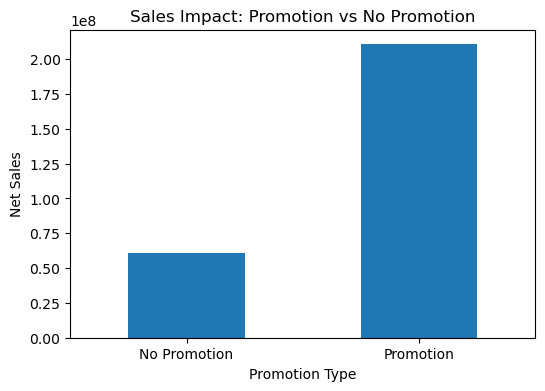

In [100]:
import matplotlib.pyplot as plt

promo_impact.plot(
    x='Promotion_Flag',
    y='Total_Sales',
    kind='bar',
    figsize=(6,4),
    legend=False
)

plt.title('Sales Impact: Promotion vs No Promotion')
plt.xlabel('Promotion Type')
plt.ylabel('Net Sales')
plt.xticks(rotation=0)
plt.show()



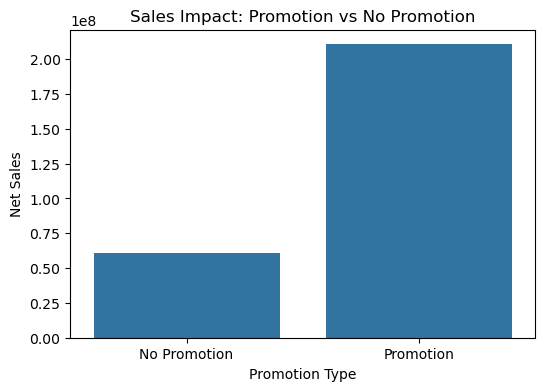

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=promo_impact,
    x='Promotion_Flag',
    y='Total_Sales'
)

plt.title('Sales Impact: Promotion vs No Promotion')
plt.xlabel('Promotion Type')
plt.ylabel('Net Sales')
plt.show()


In [102]:
promo_impact[['Promotion_Flag', 'Total_Sales']]


,Promotion_Flag,Total_Sales
0,No Promotion,6.104736e+07
1,Promotion,2.106826e+08


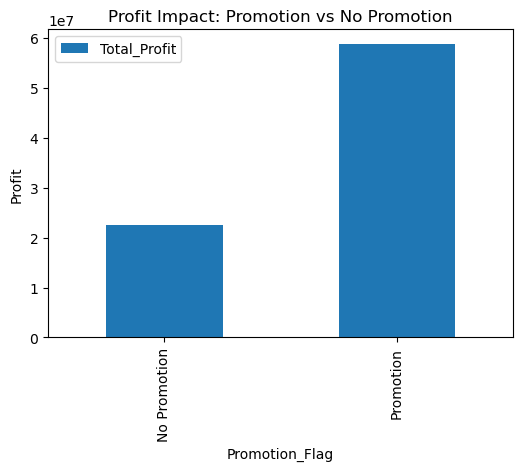

In [103]:
promo_impact.plot(
    x='Promotion_Flag', y='Total_Profit',
    kind='bar', figsize=(6,4)
)
plt.title('Profit Impact: Promotion vs No Promotion')
plt.ylabel('Profit')
plt.show()


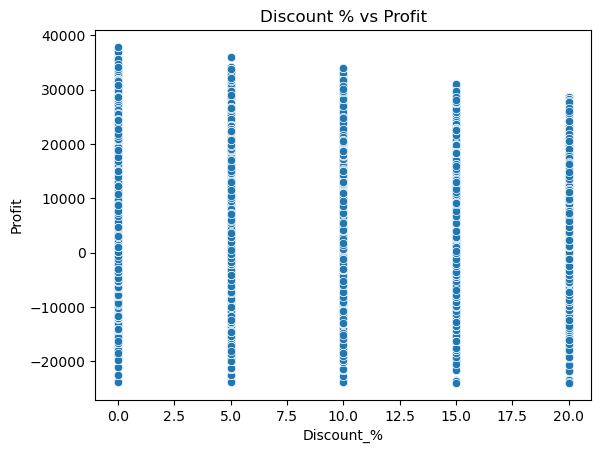

In [104]:
sns.scatterplot(
    data=df_2,
    x='Discount_%',
    y='Profit'
)
plt.title('Discount % vs Profit')
plt.show()


In [ ]:
# 7. Return analysis. 


In [144]:
df_4.head()

,Return_ID,Order_ID,Return_Date,Return_Reason,Net_Sales,Return_Year,Return_Month,Return_Day
0,R500000,O500000,2024-03-19 00:00:00+00:00,Customer Dissatisfied,911.14,2024,3,19
1,R500047,O500047,2024-01-16 00:00:00+00:00,Customer Dissatisfied,16581.31,2024,1,16
2,R500116,O500116,2024-04-04 00:00:00+00:00,Customer Dissatisfied,16343.32,2024,4,4
3,R500137,O500137,2025-06-28 00:00:00+00:00,Customer Dissatisfied,9074.24,2025,6,28
4,R500184,O500184,2024-02-16 00:00:00+00:00,Customer Dissatisfied,6225.01,2024,2,16


In [143]:
df_4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1527 entries, 0 to 1526
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype              
---  ------         --------------  -----              
 0   Return_ID      1527 non-null   object             
 1   Order_ID       1527 non-null   object             
 2   Return_Date    1527 non-null   datetime64[us, UTC]
 3   Return_Reason  1527 non-null   object             
 4   Net_Sales      1527 non-null   float64            
 5   Return_Year    1527 non-null   int32              
 6   Return_Month   1527 non-null   int32              
 7   Return_Day     1527 non-null   int32              
dtypes: datetime64[us, UTC](1), float64(1), int32(3), object(3)
memory usage: 77.7+ KB


In [145]:
df_4['Return_Date'] = pd.to_datetime(df_4['Return_Date'])


In [146]:
total_orders = df_2['Order_ID'].nunique()
returned_orders = df_4['Order_ID'].nunique()

return_rate = (returned_orders / total_orders) * 100
return_rate


6.1080000000000005

In [151]:
df_orders_returns = df_2.merge(
    df_4[['Order_ID', 'Return_Reason', 'Return_Date']],
    on='Order_ID',
    how='left'
)


In [152]:
df_orders_returns['Returned_Flag'] = np.where(
    df_orders_returns['Return_Reason'].notna(),
    'Returned',
    'Not Returned'
)


In [153]:
return_by_product = (
    df_orders_returns
    .groupby('Product_ID', as_index=False)
    .agg(
        Total_Orders=('Order_ID', 'nunique'),
        Returned_Orders=('Returned_Flag', lambda x: (x == 'Returned').sum())
    )
)


In [154]:
return_by_product['Return_Rate_%'] = (
    return_by_product['Returned_Orders'] /
    return_by_product['Total_Orders']
) * 100

return_by_product.sort_values('Return_Rate_%', ascending=False).head(10)


,Product_ID,Total_Orders,Returned_Orders,Return_Rate_%
56,P100056,27,7,25.925926
638,P100638,29,6,20.689655
786,P100786,29,6,20.689655
287,P100287,30,6,20.000000
207,P100207,30,6,20.000000
214,P100214,27,5,18.518519
779,P100779,29,5,17.241379
776,P100776,30,5,16.666667
384,P100384,36,6,16.666667
713,P100713,18,3,16.666667


In [155]:
return_reason_dist = (
    df_4['Return_Reason']
    .value_counts()
    .reset_index()
    .rename(columns={'index': 'Return_Reason', 'Return_Reason': 'Count'})
)


In [156]:
return_reason_dist


,Count,count
0,Late Delivery,421
1,Customer Dissatisfied,378
2,Damaged,369
3,Wrong Item,359


In [168]:
return_reason_dist = (
    df_4['Return_Reason']
    .value_counts()
    .reset_index()
)

return_reason_dist.columns = ['Return_Reason', 'Count']


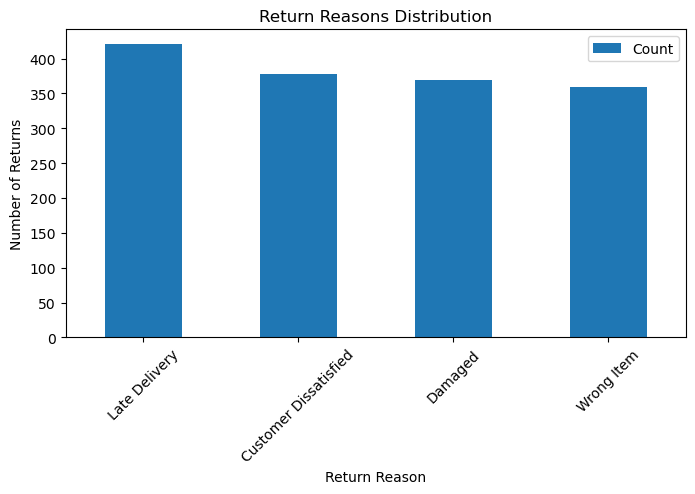

In [169]:
return_reason_dist.plot(
    x='Return_Reason',
    y='Count',
    kind='bar',
    figsize=(8,4)
)

plt.title('Return Reasons Distribution')
plt.xlabel('Return Reason')
plt.ylabel('Number of Returns')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 8. Seasonal trends. 


In [170]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [171]:
df_2['Month'] = df_2['Order_Date'].dt.month
df_2['Month_Name'] = df_2['Order_Date'].dt.month_name()
df_2['Quarter'] = df_2['Order_Date'].dt.to_period('Q').astype(str)


C:\Users\User\AppData\Local\Temp\ipykernel_2164\1094222491.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_2['Quarter'] = df_2['Order_Date'].dt.to_period('Q').astype(str)


In [172]:
monthly_seasonality = (
    df_2
    .groupby('Month_Name', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [173]:
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly_seasonality['Month_Name'] = pd.Categorical(
    monthly_seasonality['Month_Name'],
    categories=month_order,
    ordered=True
)

monthly_seasonality = monthly_seasonality.sort_values('Month_Name')
monthly_seasonality


,Month_Name,Total_Sales,Units_Sold
4,January,23611188.69,6375
3,February,20966515.81,5879
7,March,22511663.32,6292
0,April,22704933.18,6408
8,May,23688618.70,6564
6,June,21689532.24,5993
5,July,22627188.10,6207
1,August,23958696.85,6452
11,September,22225819.06,6133
10,October,22627907.36,6278


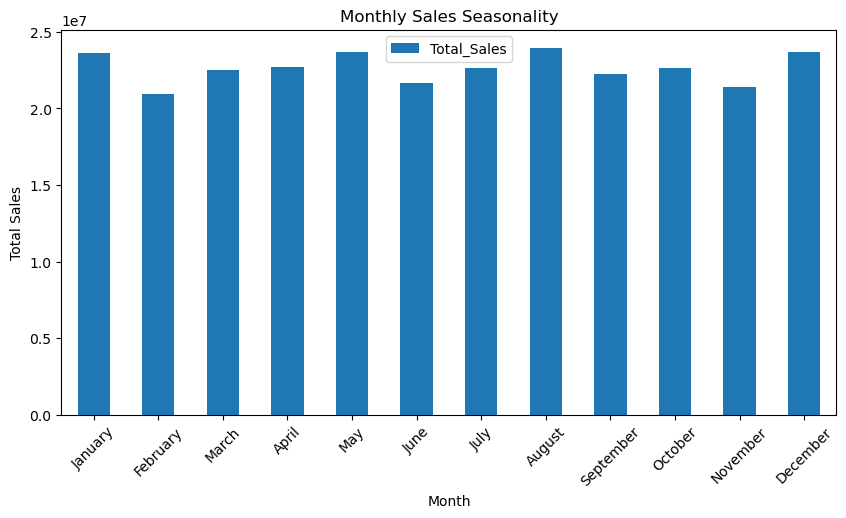

In [174]:
monthly_seasonality.plot(
    x='Month_Name',
    y='Total_Sales',
    kind='bar',
    figsize=(10,5)
)

plt.title('Monthly Sales Seasonality')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [175]:
quarterly_sales = (
    df_2
    .groupby('Quarter', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [176]:
quarterly_sales


,Quarter,Total_Sales,Units_Sold
0,2024Q1,33257028.06,9145
1,2024Q2,34194789.65,9527
2,2024Q3,34505526.59,9466
3,2024Q4,34686544.92,9554
4,2025Q1,33832339.76,9401
5,2025Q2,33888294.47,9438
6,2025Q3,34306177.42,9326
7,2025Q4,33059252.18,9137


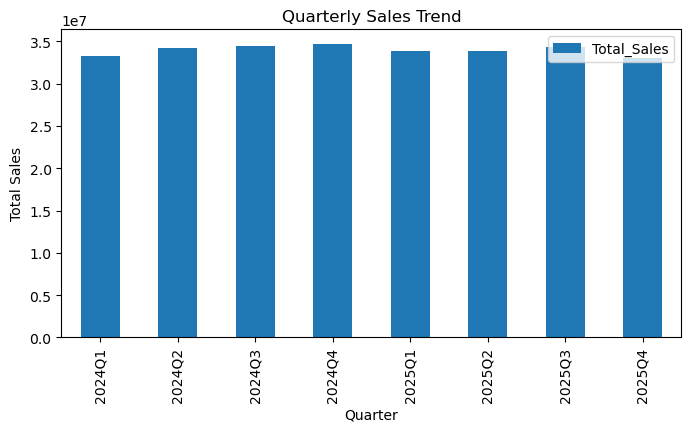

In [177]:
quarterly_sales.plot(
    x='Quarter',
    y='Total_Sales',
    kind='bar',
    figsize=(8,4)
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
# 9. Customer segmentation. 


In [178]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [179]:
analysis_date = df_2['Order_Date'].max()
analysis_date


Timestamp('2025-12-31 00:00:00+0000', tz='UTC')

In [180]:
rfm = (
    df_2
    .groupby('Customer_ID', as_index=False)
    .agg(
        Recency=('Order_Date', lambda x: (analysis_date - x.max()).days),
        Frequency=('Order_ID', 'nunique'),
        Monetary=('Net_Sales', 'sum')
    )
)


In [181]:
rfm.head()


,Customer_ID,Recency,Frequency,Monetary
0,C200000,64,7,88485.90
1,C200001,399,2,22325.69
2,C200002,63,6,69725.42
3,C200003,3,6,76260.04
4,C200004,16,2,25977.73


In [182]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])


In [183]:
rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(int)


In [184]:
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)


In [185]:
def segment_customer(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'High Value'
    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Recent Customers'
    elif row['F_Score'] == 1 and row['M_Score'] == 1:
        return 'Low Value'
    else:
        return 'Medium Value'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)


In [186]:
rfm['Customer_Segment'].value_counts()


Customer_Segment
Recent Customers    1427
Medium Value        1310
High Value          1080
Low Value            604
Loyal Customers      550
Name: count, dtype: int64

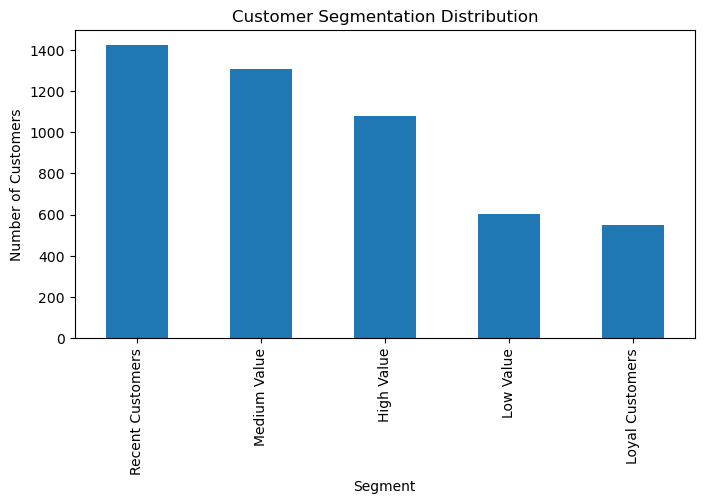

In [187]:
rfm['Customer_Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,4)
)
plt.title('Customer Segmentation Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# 10. Recommendations. 


In [ ]:
#  1. Product & Pricing Optimization
# Focus on high-revenue and high-margin products to maximize profitability.
# Review pricing and cost structures for low-margin or loss-making SKUs.
# Reduce or eliminate deep discounts on products with consistently poor margins.

# 2. Store & Regional Strategy
# Allocate inventory and marketing resources toward top-performing stores and regions.
# Investigate operational inefficiencies in underperforming stores.
# Apply best practices from high-performing locations to weaker regions.

# 3. Customer Retention Focus
# Prioritize high-value and loyal customers identified through segmentation.
# Implement loyalty programs and personalized offers to increase repeat purchases.
# Improve onboarding strategies to convert new customers into returning customers.

# 4. Promotion Effectiveness
# Use promotions strategically to drive volume without significantly impacting profit.
# Avoid high discounts on low-margin products.
# continuously monitor promotion performance to ensure positive ROI.

# 5. Return Reduction Measures
# Analyze high-return products and major return reasons such as customer dissatisfaction.
# Improve product quality checks and product information clarity.
# Address recurring return issues to minimize revenue leakage.

# 6. Seasonal Planning
# Align inventory and staffing decisions with seasonal sales trends.
# Run targeted promotions during low-demand periods.
# Maximize revenue during peak seasons through better stock availability.

# 7. Data-Driven Decision Making
# Track key KPIs such as Sales, Profit, AOV, Return Rate, and Repeat Rate regularly.
# Use dashboards and reports for continuous monitoring.
# Leverage EDA insights to support future forecasting and strategic planning.

# ✅ Conclusion
# The analysis highlights key opportunities to improve profitability, customer retention, and operational efficiency. Implementing these recommendations can help drive sustainable, data-driven business growth.


In [ ]:
# 8. Key KPIs - Sales, Margin%, GMV, AOV, Units Sold, Repeat Rate, Return Rate, Growth.

In [188]:
total_sales = df_2['Net_Sales'].sum()
total_sales


np.float64(271729953.05)

In [189]:
total_profit = df_2['Profit'].sum()

margin_pct = (total_profit / total_sales) * 100
margin_pct


np.float64(29.95542278514371)

In [190]:
gmv = df_2['Gross_Sales'].sum()
gmv


np.float64(301781241.06)

In [191]:
gmv = (df_2['Net_Sales'] + df_2['Discount_Amount']).sum()
gmv


np.float64(301781242.25)

In [192]:
total_orders = df_2['Order_ID'].nunique()

aov = total_sales / total_orders
aov


np.float64(10869.198122)

In [193]:
units_sold = df_2['Quantity'].sum()
units_sold


np.int64(74994)

In [194]:
customer_orders = (
    df_2
    .groupby('Customer_ID')['Order_ID']
    .nunique()
)

repeat_customers = customer_orders[customer_orders > 1].count()
total_customers = customer_orders.count()

repeat_rate = (repeat_customers / total_customers) * 100
repeat_rate


np.float64(96.60028163347415)

In [195]:
returned_orders = df_4['Order_ID'].nunique()

return_rate = (returned_orders / total_orders) * 100
return_rate


6.1080000000000005

In [196]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])

monthly_sales = (
    df_2
    .groupby(df_2['Order_Date'].dt.to_period('M'))['Net_Sales']
    .sum()
    .reset_index()
)

monthly_sales['Order_Date'] = monthly_sales['Order_Date'].astype(str)
monthly_sales


C:\Users\User\AppData\Local\Temp\ipykernel_2164\2606539118.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .groupby(df_2['Order_Date'].dt.to_period('M'))['Net_Sales']


,Order_Date,Net_Sales
0,2024-01,11896728.70
1,2024-02,10505337.63
2,2024-03,10854961.73
3,2024-04,11308847.40
4,2024-05,11960181.11
5,2024-06,10925761.14
6,2024-07,11098639.14
7,2024-08,11703243.12
8,2024-09,11703644.33
9,2024-10,12058129.15


In [197]:
monthly_sales['MoM_Growth_%'] = (
    monthly_sales['Net_Sales']
    .pct_change() * 100
)

monthly_sales


,Order_Date,Net_Sales,MoM_Growth_%
0,2024-01,11896728.70,NaN
1,2024-02,10505337.63,-11.695577
2,2024-03,10854961.73,3.328062
3,2024-04,11308847.40,4.181366
4,2024-05,11960181.11,5.759506
5,2024-06,10925761.14,-8.648865
6,2024-07,11098639.14,1.582297
7,2024-08,11703243.12,5.447551
8,2024-09,11703644.33,0.003428
9,2024-10,12058129.15,3.028841


In [198]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Sales',
        'Margin %',
        'GMV',
        'AOV',
        'Units Sold',
        'Repeat Rate %',
        'Return Rate %'
    ],
    'Value': [
        total_sales,
        margin_pct,
        gmv,
        aov,
        units_sold,
        repeat_rate,
        return_rate
    ]
})

kpi_summary


,KPI,Value
0,Total Sales,2.717300e+08
1,Margin %,2.995542e+01
2,GMV,3.017812e+08
3,AOV,1.086920e+04
4,Units Sold,7.499400e+04
5,Repeat Rate %,9.660028e+01
6,Return Rate %,6.108000e+00


In [ ]:
# 9.  EDA Analysis Patterns 
# 1. Monthly Revenue Trend 

In [200]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [201]:
df_2['Year'] = df_2['Order_Date'].dt.year
df_2['Month'] = df_2['Order_Date'].dt.month
df_2['Month_Name'] = df_2['Order_Date'].dt.month_name()


In [202]:
monthly_revenue = (
    df_2
    .groupby(['Year', 'Month'], as_index=False)
    .agg(Monthly_Revenue=('Net_Sales', 'sum'))
    .sort_values(['Year', 'Month'])
)


In [203]:
monthly_revenue


,Year,Month,Monthly_Revenue
0,2024,1,11896728.70
1,2024,2,10505337.63
2,2024,3,10854961.73
3,2024,4,11308847.40
4,2024,5,11960181.11
5,2024,6,10925761.14
6,2024,7,11098639.14
7,2024,8,11703243.12
8,2024,9,11703644.33
9,2024,10,12058129.15


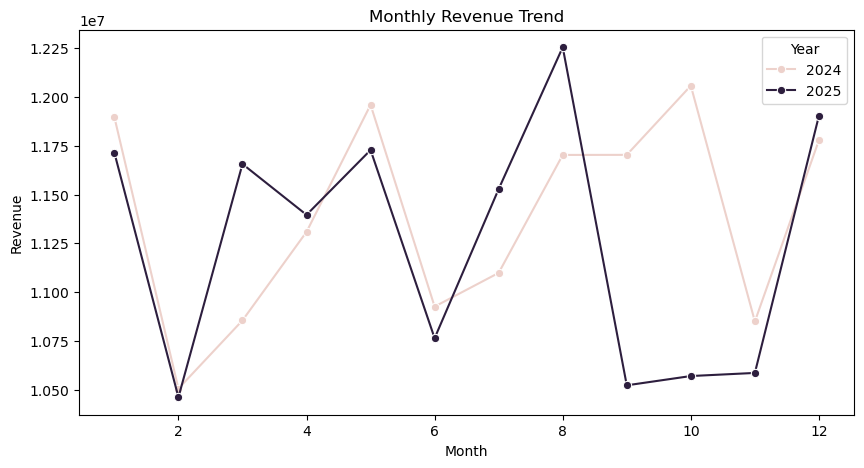

In [204]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(
    data=monthly_revenue,
    x='Month',
    y='Monthly_Revenue',
    hue='Year',
    marker='o'
)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()


In [ ]:
# 2. Weekly Pattern 


In [205]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [206]:
df_2['Day_of_Week'] = df_2['Order_Date'].dt.day_name()


In [207]:
weekly_sales = (
    df_2
    .groupby('Day_of_Week', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [208]:
day_order = [
    'Monday','Tuesday','Wednesday',
    'Thursday','Friday','Saturday','Sunday'
]

weekly_sales['Day_of_Week'] = pd.Categorical(
    weekly_sales['Day_of_Week'],
    categories=day_order,
    ordered=True
)

weekly_sales = weekly_sales.sort_values('Day_of_Week')
weekly_sales


,Day_of_Week,Total_Sales,Orders
1,Monday,38456005.48,3542
5,Tuesday,39546130.03,3663
6,Wednesday,38516409.59,3596
4,Thursday,39093383.41,3586
0,Friday,39407171.92,3579
2,Saturday,38448337.52,3475
3,Sunday,38262515.10,3559


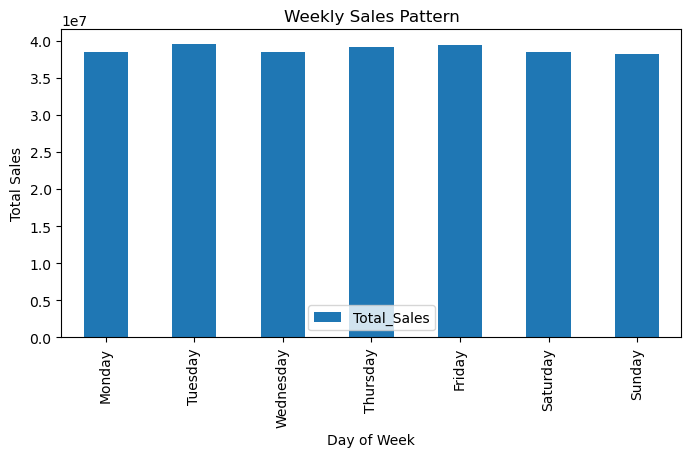

In [209]:
weekly_sales.plot(
    x='Day_of_Week',
    y='Total_Sales',
    kind='bar',
    figsize=(8,4)
)

plt.title('Weekly Sales Pattern')
plt.xlabel('Day of Week')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
# 3. Daily Variation 


In [210]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [211]:
daily_sales = (
    df_2
    .groupby(df_2['Order_Date'].dt.date, as_index=False)
    .agg(
        Daily_Sales=('Net_Sales', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
)


C:\Users\User\AppData\Local\Temp\ipykernel_2164\3531134169.py:4: FutureWarning: A grouping was used that is not in the columns of the DataFrame and so was excluded from the result. This grouping will be included in a future version of pandas. Add the grouping as a column of the DataFrame to silence this warning.
  .agg(


In [212]:
daily_sales.rename(columns={'Order_Date': 'Date'}, inplace=True)
daily_sales.head()


,Daily_Sales,Orders,Units_Sold
0,333074.66,36,95
1,488445.49,42,137
2,365302.01,30,87
3,299227.36,34,93
4,330132.12,29,76


In [220]:
print(daily_sales.columns)


Index(['Daily_Sales', 'Orders', 'Units_Sold'], dtype='object')


In [214]:
daily_sales.sort_values('Daily_Sales', ascending=False).head(5)


,Daily_Sales,Orders,Units_Sold
242,611344.03,51,154
218,606928.03,49,146
15,604928.57,45,142
250,601481.96,51,168
283,598713.69,46,133


In [215]:
daily_sales.sort_values('Daily_Sales').head(5)


,Daily_Sales,Orders,Units_Sold
228,131893.75,19,53
681,151717.46,27,65
340,165201.29,25,72
68,170699.66,21,58
451,189130.62,23,63


In [223]:
daily_sales = (
    df_2
    .groupby(df_2['Order_Date'].dt.date)
    .agg(
        Daily_Sales=('Net_Sales', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
    .reset_index()
)


In [225]:
daily_sales = (
    df_2
    .assign(Date=df_2['Order_Date'].dt.date)
    .groupby('Date', as_index=False)
    .agg(
        Daily_Sales=('Net_Sales', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
)


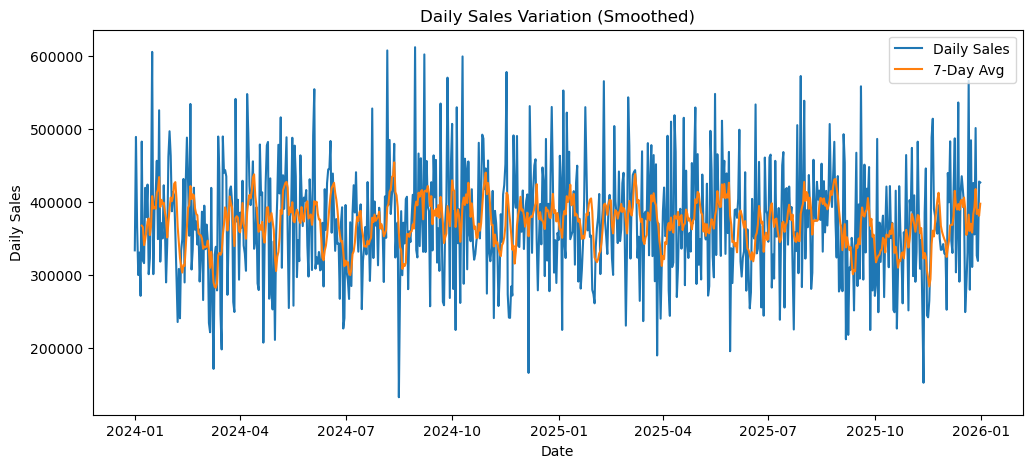

In [228]:
daily_sales['Rolling_7_Day_Sales'] = daily_sales['Daily_Sales'].rolling(7).mean()

plt.figure(figsize=(12,5))
sns.lineplot(data=daily_sales, x='Date', y='Daily_Sales', label='Daily Sales')
sns.lineplot(data=daily_sales, x='Date', y='Rolling_7_Day_Sales', label='7-Day Avg')
plt.title('Daily Sales Variation (Smoothed)')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.show()


In [ ]:
# 4. YoY/MoM Growth 


In [230]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [231]:
df_2['Year_Month'] = df_2['Order_Date'].dt.to_period('M')


C:\Users\User\AppData\Local\Temp\ipykernel_2164\1724368797.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_2['Year_Month'] = df_2['Order_Date'].dt.to_period('M')


In [232]:
monthly_sales = (
    df_2
    .groupby('Year_Month', as_index=False)
    .agg(Monthly_Revenue=('Net_Sales', 'sum'))
)


In [233]:
monthly_sales['Year_Month'] = monthly_sales['Year_Month'].astype(str)
monthly_sales


,Year_Month,Monthly_Revenue
0,2024-01,11896728.70
1,2024-02,10505337.63
2,2024-03,10854961.73
3,2024-04,11308847.40
4,2024-05,11960181.11
5,2024-06,10925761.14
6,2024-07,11098639.14
7,2024-08,11703243.12
8,2024-09,11703644.33
9,2024-10,12058129.15


In [234]:
monthly_sales['MoM_Growth_%'] = (
    monthly_sales['Monthly_Revenue']
    .pct_change() * 100
)


In [235]:
monthly_sales


,Year_Month,Monthly_Revenue,MoM_Growth_%
0,2024-01,11896728.70,NaN
1,2024-02,10505337.63,-11.695577
2,2024-03,10854961.73,3.328062
3,2024-04,11308847.40,4.181366
4,2024-05,11960181.11,5.759506
5,2024-06,10925761.14,-8.648865
6,2024-07,11098639.14,1.582297
7,2024-08,11703243.12,5.447551
8,2024-09,11703644.33,0.003428
9,2024-10,12058129.15,3.028841


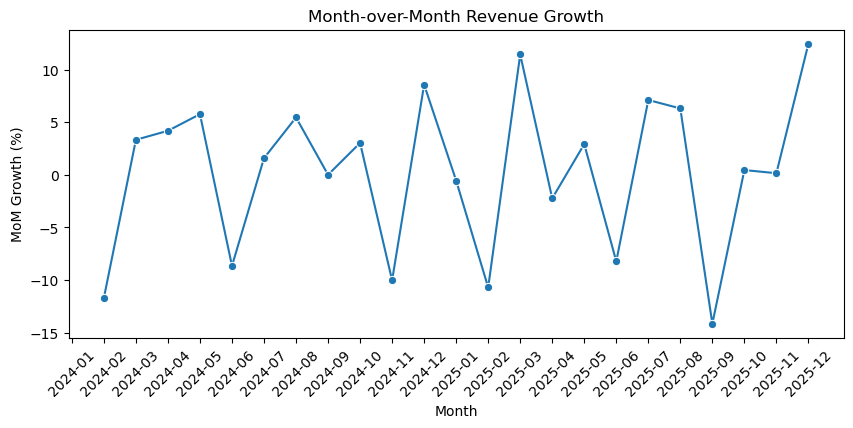

In [236]:
plt.figure(figsize=(10,4))
sns.lineplot(
    data=monthly_sales,
    x='Year_Month',
    y='MoM_Growth_%',
    marker='o'
)
plt.title('Month-over-Month Revenue Growth')
plt.xlabel('Month')
plt.ylabel('MoM Growth (%)')
plt.xticks(rotation=45)
plt.show()


In [237]:
df_2['Year'] = df_2['Order_Date'].dt.year
df_2['Month'] = df_2['Order_Date'].dt.month


In [238]:
yoy_sales = (
    df_2
    .groupby(['Year', 'Month'], as_index=False)
    .agg(Monthly_Revenue=('Net_Sales', 'sum'))
)


In [239]:
yoy_sales['YoY_Growth_%'] = (
    yoy_sales
    .sort_values(['Month','Year'])
    .groupby('Month')['Monthly_Revenue']
    .pct_change() * 100
)


In [240]:
yoy_sales


,Year,Month,Monthly_Revenue,YoY_Growth_%
0,2024,1,11896728.70,NaN
1,2024,2,10505337.63,NaN
2,2024,3,10854961.73,NaN
3,2024,4,11308847.40,NaN
4,2024,5,11960181.11,NaN
5,2024,6,10925761.14,NaN
6,2024,7,11098639.14,NaN
7,2024,8,11703243.12,NaN
8,2024,9,11703644.33,NaN
9,2024,10,12058129.15,NaN


In [ ]:
# 5. Category Sales 

In [241]:
df_category_sales = df_2.merge(
    df_3[['Product_ID', 'Category']],
    on='Product_ID',
    how='left'
)


In [242]:
df_category_sales.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,...,Payment_Mode,Order_Status,Year,Month,Promotion_Flag,Month_Name,Quarter,Day_of_Week,Year_Month,Category
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,...,Credit Card,Completed,2024,6,No Promotion,June,2024Q2,Sunday,2024-06,Grocery
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,...,Wallet,Completed,2024,10,No Promotion,October,2024Q4,Thursday,2024-10,Electronics
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,...,Credit Card,Completed,2024,4,No Promotion,April,2024Q2,Monday,2024-04,Home & Kitchen
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,...,Debit Card,Completed,2024,12,No Promotion,December,2024Q4,Tuesday,2024-12,Beauty
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,...,Credit Card,Completed,2025,3,No Promotion,March,2025Q1,Monday,2025-03,Electronics


In [243]:
category_sales = (
    df_category_sales
    .groupby('Category', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [244]:
category_sales


,Category,Total_Sales,Units_Sold,Orders
0,Beauty,43551398.54,12662,4232
1,Electronics,47378907.84,13369,4498
2,Fashion,39991097.05,11933,3987
3,Grocery,51968249.37,14373,4742
4,Home & Kitchen,44168442.58,11051,3715
5,Sports,44671857.67,11606,3826


In [245]:
category_sales_sorted = category_sales.sort_values(
    by='Total_Sales', ascending=False
)

category_sales_sorted


,Category,Total_Sales,Units_Sold,Orders
3,Grocery,51968249.37,14373,4742
1,Electronics,47378907.84,13369,4498
5,Sports,44671857.67,11606,3826
4,Home & Kitchen,44168442.58,11051,3715
0,Beauty,43551398.54,12662,4232
2,Fashion,39991097.05,11933,3987


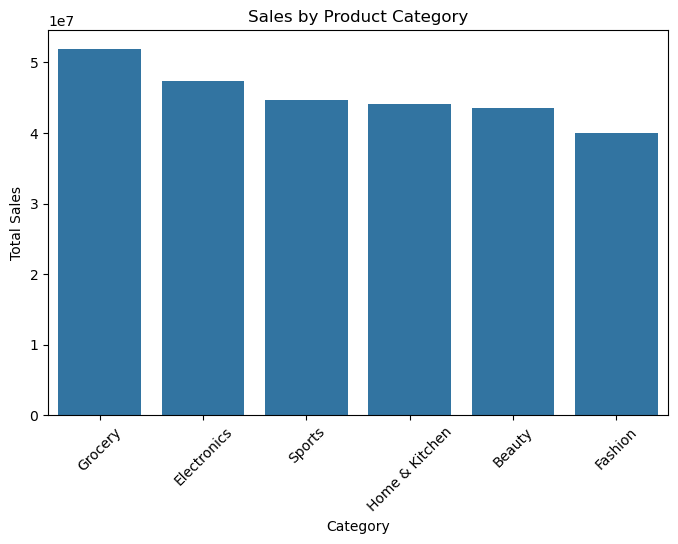

In [246]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=category_sales_sorted,
    x='Category',
    y='Total_Sales'
)
plt.title('Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 6. Brand Revenue

In [247]:
df_brand_sales = df_2.merge(
    df_3[['Product_ID', 'Brand']],
    on='Product_ID',
    how='left'
)


In [248]:
df_brand_sales.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,...,Payment_Mode,Order_Status,Year,Month,Promotion_Flag,Month_Name,Quarter,Day_of_Week,Year_Month,Brand
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,...,Credit Card,Completed,2024,6,No Promotion,June,2024Q2,Sunday,2024-06,Nova
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,...,Wallet,Completed,2024,10,No Promotion,October,2024Q4,Thursday,2024-10,Nova
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,...,Credit Card,Completed,2024,4,No Promotion,April,2024Q2,Monday,2024-04,Nova
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,...,Debit Card,Completed,2024,12,No Promotion,December,2024Q4,Tuesday,2024-12,Pulse
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,...,Credit Card,Completed,2025,3,No Promotion,March,2025Q1,Monday,2025-03,Alpha


In [249]:
brand_revenue = (
    df_brand_sales
    .groupby('Brand', as_index=False)
    .agg(
        Total_Revenue=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [250]:
brand_revenue


,Brand,Total_Revenue,Units_Sold,Orders
0,Alpha,47856460.56,12514,4172
1,Nova,45563604.43,13343,4455
2,Orion,38434001.45,10487,3451
3,Pulse,45844994.09,12608,4253
4,Vertex,45804362.16,12979,4346
5,Zen,48226530.36,13063,4323


In [251]:
brand_revenue_sorted = brand_revenue.sort_values(
    by='Total_Revenue', ascending=False
)


In [252]:
brand_revenue_sorted


,Brand,Total_Revenue,Units_Sold,Orders
5,Zen,48226530.36,13063,4323
0,Alpha,47856460.56,12514,4172
3,Pulse,45844994.09,12608,4253
4,Vertex,45804362.16,12979,4346
1,Nova,45563604.43,13343,4455
2,Orion,38434001.45,10487,3451


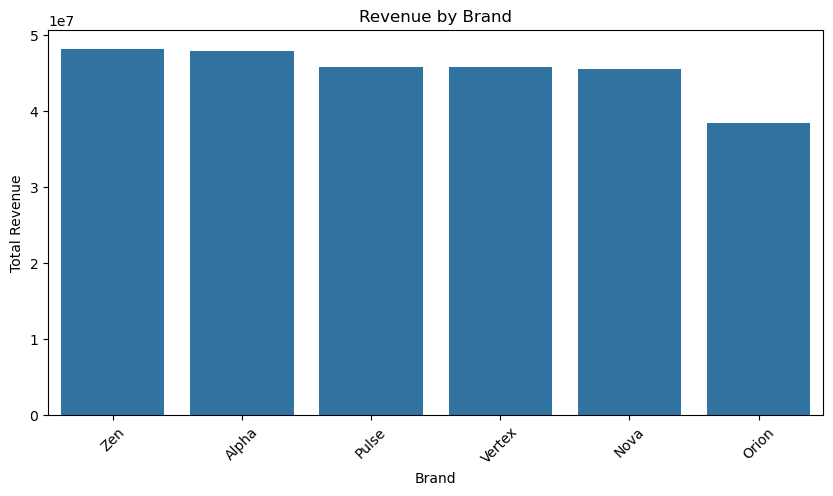

In [253]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=brand_revenue_sorted,
    x='Brand',
    y='Total_Revenue'
)
plt.title('Revenue by Brand')
plt.xlabel('Brand')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 7. Top 10 Products 

In [254]:
product_sales = (
    df_2
    .groupby('Product_ID', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [255]:
product_sales.head()


,Product_ID,Total_Sales,Units_Sold,Orders
0,P100000,497036.80,125,40
1,P100001,769737.26,108,38
2,P100002,554178.54,82,33
3,P100003,38987.28,101,30
4,P100004,106670.37,84,27


In [256]:
top_10_products = product_sales.sort_values(
    by='Total_Sales', ascending=False
).head(10)

top_10_products


,Product_ID,Total_Sales,Units_Sold,Orders
569,P100569,905438.70,125,36
690,P100690,882595.03,130,43
508,P100508,848843.01,141,43
640,P100640,845533.84,122,39
666,P100666,828209.27,115,33
355,P100355,826129.63,130,45
635,P100635,816920.57,116,34
652,P100652,815493.64,121,37
237,P100237,811521.72,123,38
337,P100337,810546.14,117,41


In [257]:
top_10_products = top_10_products.merge(
    df_3[['Product_ID', 'Product_Name']],
    on='Product_ID',
    how='left'
)


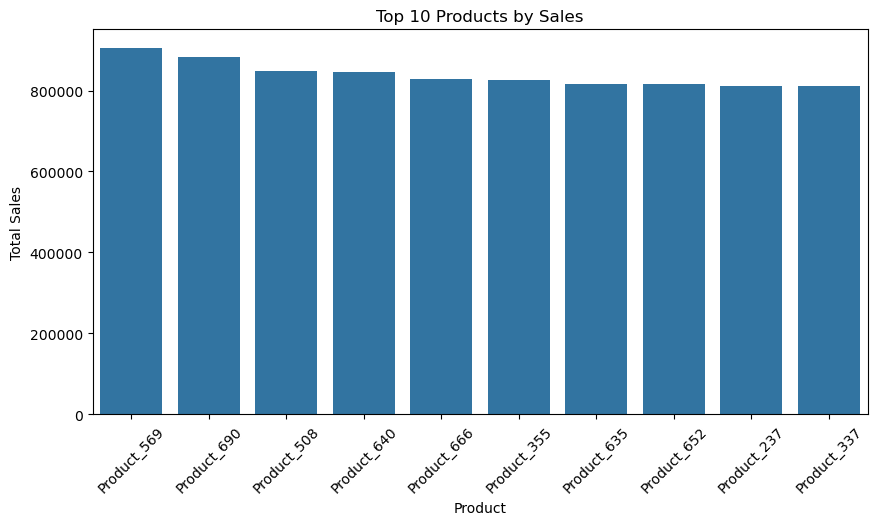

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_10_products,
    x='Product_Name',
    y='Total_Sales'
)
plt.title('Top 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 8. Bottom 10 Products

In [259]:
product_sales.head()


,Product_ID,Total_Sales,Units_Sold,Orders
0,P100000,497036.80,125,40
1,P100001,769737.26,108,38
2,P100002,554178.54,82,33
3,P100003,38987.28,101,30
4,P100004,106670.37,84,27


In [260]:
product_sales = (
    df_2
    .groupby('Product_ID', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [261]:
bottom_10_products = product_sales.sort_values(
    by='Total_Sales', ascending=True
).head(10)

bottom_10_products


,Product_ID,Total_Sales,Units_Sold,Orders
741,P100741,6761.22,93,31
464,P100464,7197.96,86,32
431,P100431,7212.65,66,23
23,P100023,8357.32,60,23
748,P100748,8577.43,87,27
58,P100058,9351.68,97,31
38,P100038,10624.25,99,33
665,P100665,10919.54,81,26
769,P100769,11249.80,108,33
432,P100432,11642.92,93,28


In [262]:
bottom_10_products = bottom_10_products.merge(
    df_3[['Product_ID', 'Product_Name']],
    on='Product_ID',
    how='left'
)


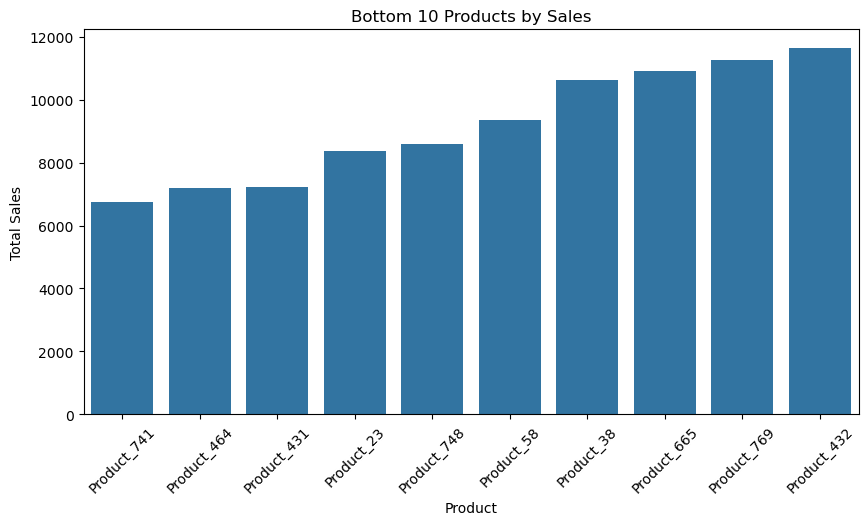

In [263]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=bottom_10_products,
    x='Product_Name',
    y='Total_Sales'
)
plt.title('Bottom 10 Products by Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 9. Store Performance 

In [3]:
df_store_sales = df_2.merge(
    df_5[['Store_ID', 'Store_Name', 'Region']],
    on='Store_ID',
    how='left'
)


In [4]:
df_store_sales.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,Net_Sales,Profit,Payment_Mode,Order_Status,Store_Name,Region
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,81.07,-1699.96,Credit Card,Completed,Store_96,South
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,110.25,-3723.39,Wallet,Completed,Store_103,North
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,114.56,-2818.43,Credit Card,Completed,Store_69,North
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,123.61,-2913.46,Debit Card,Completed,Store_86,West
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,140.70,-3216.95,Credit Card,Completed,Store_51,South


In [5]:
store_perf = (
    df_store_sales
    .groupby(['Store_ID', 'Store_Name', 'Region'], as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [6]:
store_perf.head()


,Store_ID,Store_Name,Region,Total_Sales,Total_Profit,Units_Sold,Orders
0,S3000,Store_0,South,2071075.40,567588.49,573,196
1,S3001,Store_1,North,2475852.93,734191.78,670,220
2,S3002,Store_2,South,2144925.36,388281.41,674,226
3,S3003,Store_3,North,2346490.60,628762.96,674,215
4,S3004,Store_4,North,2036826.65,499261.79,582,197


In [7]:
top_10_stores = store_perf.sort_values(
    by='Total_Sales', ascending=False
).head(10)

top_10_stores


,Store_ID,Store_Name,Region,Total_Sales,Total_Profit,Units_Sold,Orders
21,S3021,Store_21,North,2706543.71,1107581.97,699,232
61,S3061,Store_61,West,2704558.81,785141.10,741,228
89,S3089,Store_89,South,2701550.94,1038390.11,674,226
34,S3034,Store_34,West,2692652.53,1004877.18,721,235
82,S3082,Store_82,West,2657002.32,1142625.23,685,228
75,S3075,Store_75,South,2642221.84,877045.07,696,235
67,S3067,Store_67,South,2642010.21,882913.92,701,226
60,S3060,Store_60,West,2598203.12,904790.55,695,224
30,S3030,Store_30,West,2585166.94,894044.89,657,213
112,S3112,Store_112,North,2585077.45,790388.91,674,221


In [8]:
bottom_10_stores = store_perf.sort_values(
    by='Total_Sales', ascending=True
).head(10)

bottom_10_stores


,Store_ID,Store_Name,Region,Total_Sales,Total_Profit,Units_Sold,Orders
39,S3039,Store_39,East,1726572.60,530874.09,515,176
52,S3052,Store_52,North,1768097.57,393567.08,510,177
78,S3078,Store_78,West,1823474.35,447495.07,549,185
79,S3079,Store_79,North,1848357.05,382933.57,534,186
64,S3064,Store_64,South,1906893.11,359330.38,589,204
68,S3068,Store_68,East,1926708.75,411559.71,586,193
27,S3027,Store_27,West,1936075.68,578360.41,553,190
48,S3048,Store_48,North,1938239.30,521925.82,540,184
83,S3083,Store_83,West,1939968.46,550281.43,548,194
66,S3066,Store_66,South,1940180.18,521468.61,581,205


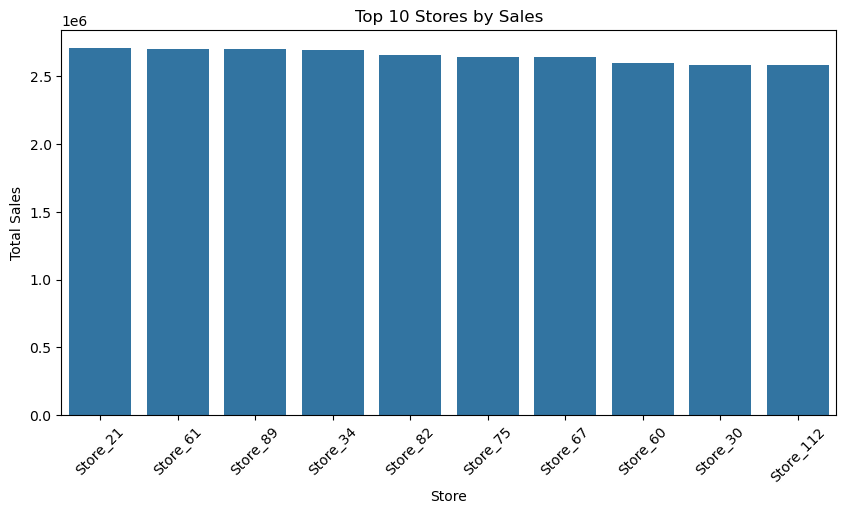

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(
    data=top_10_stores,
    x='Store_Name',
    y='Total_Sales'
)
plt.title('Top 10 Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


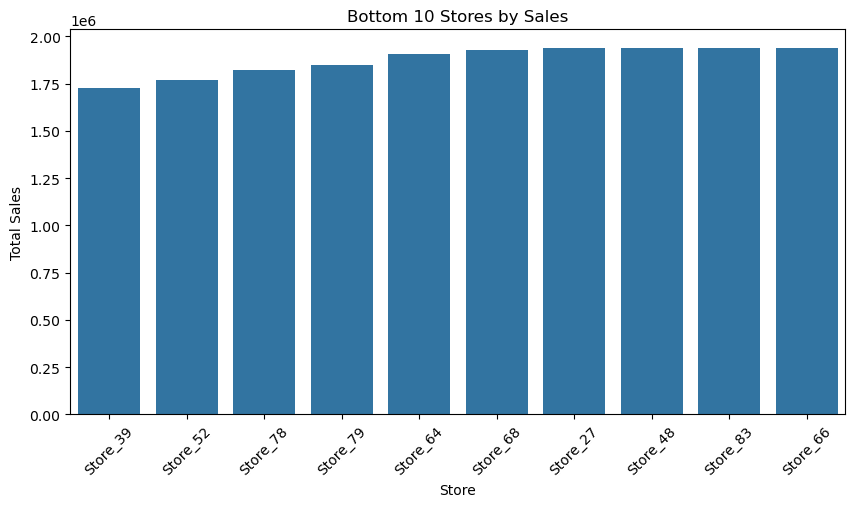

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=bottom_10_stores,
    x='Store_Name',
    y='Total_Sales'
)
plt.title('Bottom 10 Stores by Sales')
plt.xlabel('Store')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 10. Region Heatmap

In [12]:
df_region_sales = df_2.merge(
    df_5[['Store_ID', 'Region']],
    on='Store_ID',
    how='left'
)


In [13]:
df_region_sales.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,Net_Sales,Profit,Payment_Mode,Order_Status,Region
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,81.07,-1699.96,Credit Card,Completed,South
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,110.25,-3723.39,Wallet,Completed,North
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,114.56,-2818.43,Credit Card,Completed,North
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,123.61,-2913.46,Debit Card,Completed,West
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,140.70,-3216.95,Credit Card,Completed,South


In [14]:
region_perf = (
    df_region_sales
    .groupby('Region', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Units_Sold=('Quantity', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


In [15]:
region_perf


,Region,Total_Sales,Total_Profit,Units_Sold,Orders
0,East,62999295.48,19159015.13,17384,5755
1,North,69289435.82,20018264.14,19196,6466
2,South,74921024.74,22421976.37,20657,6903
3,West,64520197.01,19798600.63,17757,5876


In [16]:
region_heatmap_data = (
    region_perf
    .set_index('Region')[['Total_Sales', 'Total_Profit', 'Units_Sold']]
)


In [17]:
region_heatmap_norm = (
    region_heatmap_data - region_heatmap_data.min()
) / (region_heatmap_data.max() - region_heatmap_data.min())


In [105]:
print(region_heatmap_norm)
print(type(region_heatmap_norm))


        Total_Sales  Total_Profit  Units_Sold
Region                                       
East       0.000000      0.000000         0.0
North      0.527620      0.263334    0.553621
South      1.000000      1.000000         1.0
West       0.127574      0.196014    0.113963
<class 'pandas.core.frame.DataFrame'>


In [106]:
import pandas as pd

print(isinstance(region_heatmap_norm, pd.DataFrame))


True


In [107]:
region_heatmap_norm = pd.DataFrame(region_heatmap_norm)


In [108]:
print(region_heatmap_norm.isnull().sum())
print(region_heatmap_norm.shape)


Total_Sales     0
Total_Profit    0
Units_Sold      0
dtype: int64
(4, 3)


In [109]:
region_heatmap_norm = region_heatmap_norm.fillna(0)


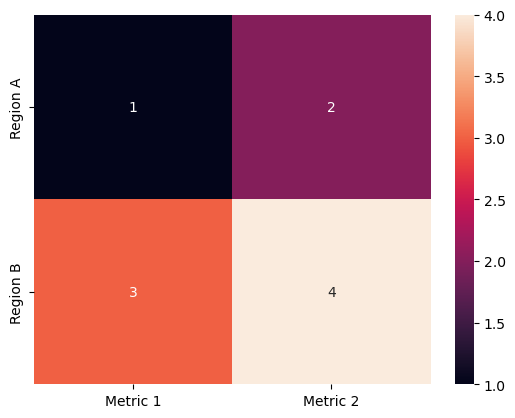

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

test_data = pd.DataFrame(
    [[1, 2], [3, 4]],
    index=["Region A", "Region B"],
    columns=["Metric 1", "Metric 2"]
)

sns.heatmap(test_data, annot=True)
plt.show()



In [ ]:
# 11. Customer Acquisition 


In [19]:
df_1['Join_Date'] = pd.to_datetime(df_1['Join_Date'])


In [20]:
df_1['Join_Year'] = df_1['Join_Date'].dt.year
df_1['Join_Month'] = df_1['Join_Date'].dt.month
df_1['Join_Month_Name'] = df_1['Join_Date'].dt.month_name()


In [21]:
customer_acquisition = (
    df_1
    .groupby(['Join_Year', 'Join_Month'], as_index=False)
    .agg(New_Customers=('Customer_ID', 'nunique'))
    .sort_values(['Join_Year', 'Join_Month'])
)


In [22]:
customer_acquisition


,Join_Year,Join_Month,New_Customers
0,2021,4,110
1,2021,5,144
2,2021,6,169
3,2021,7,174
4,2021,8,153
5,2021,9,169
6,2021,10,157
7,2021,11,156
8,2021,12,157
9,2022,1,169


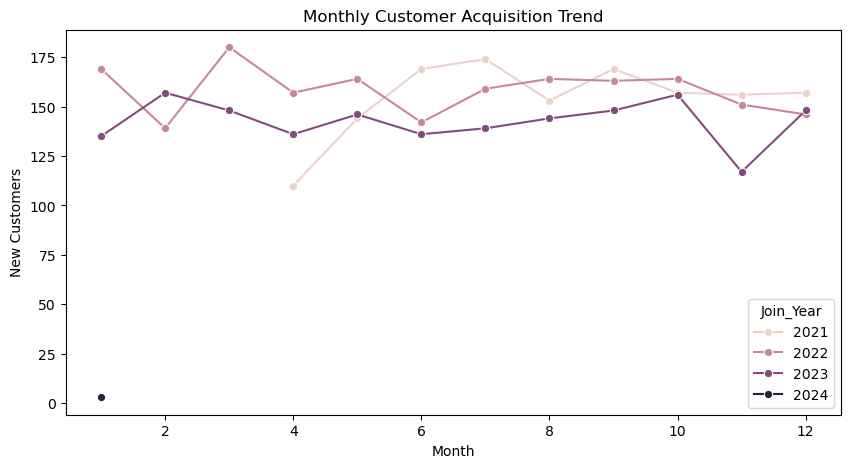

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.lineplot(
    data=customer_acquisition,
    x='Join_Month',
    y='New_Customers',
    hue='Join_Year',
    marker='o'
)
plt.title('Monthly Customer Acquisition Trend')
plt.xlabel('Month')
plt.ylabel('New Customers')
plt.show()


In [ ]:
# 12. New vs Returning 


In [24]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [25]:
first_purchase = (
    df_2
    .groupby('Customer_ID')['Order_Date']
    .min()
    .reset_index()
    .rename(columns={'Order_Date': 'First_Purchase_Date'})
)


In [26]:
df_customer_orders = df_2.merge(
    first_purchase,
    on='Customer_ID',
    how='left'
)


In [27]:
df_customer_orders.head()


,Order_ID,Order_Date,Customer_ID,Product_ID,Store_ID,Quantity,Unit_Price,Discount_%,Discount_Amount,Gross_Sales,Net_Sales,Profit,Payment_Mode,Order_Status,First_Purchase_Date
0,O517734,2024-06-09 00:00:00+00:00,C204221,P100741,S3096,1,81.07,0,0.0,81.07,81.07,-1699.96,Credit Card,Completed,2024-06-09 00:00:00+00:00
1,O500134,2024-10-31 00:00:00+00:00,C204431,P100748,S3103,1,110.25,0,0.0,110.25,110.25,-3723.39,Wallet,Completed,2024-06-23 00:00:00+00:00
2,O506628,2024-04-29 00:00:00+00:00,C202960,P100769,S3069,1,114.56,0,0.0,114.56,114.56,-2818.43,Credit Card,Completed,2024-02-16 00:00:00+00:00
3,O503674,2024-12-17 00:00:00+00:00,C202293,P100431,S3086,1,123.61,0,0.0,123.61,123.61,-2913.46,Debit Card,Completed,2024-09-18 00:00:00+00:00
4,O509265,2025-03-03 00:00:00+00:00,C200150,P100432,S3051,1,140.70,0,0.0,140.70,140.70,-3216.95,Credit Card,Completed,2024-01-04 00:00:00+00:00


In [30]:
df_customer_orders['Customer_Type'] = np.where(
    df_customer_orders['Order_Date'] == df_customer_orders['First_Purchase_Date'],
    'New',
    'Returning'
)


In [31]:
df_customer_orders['Customer_Type'].value_counts()


Customer_Type
Returning    20017
New           4983
Name: count, dtype: int64

In [32]:
customer_type_revenue = (
    df_customer_orders
    .groupby('Customer_Type', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Orders=('Order_ID', 'nunique')
    )
)


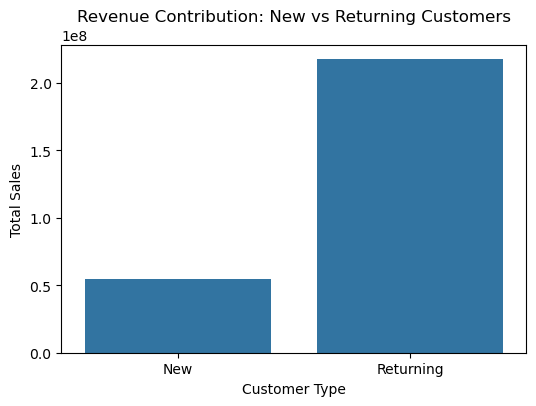

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=customer_type_revenue,
    x='Customer_Type',
    y='Total_Sales'
)
plt.title('Revenue Contribution: New vs Returning Customers')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.show()


In [ ]:
# 13. RFM Segments 


In [34]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])


In [35]:
analysis_date = df_2['Order_Date'].max()
analysis_date


Timestamp('2025-12-31 00:00:00+0000', tz='UTC')

In [36]:
rfm = (
    df_2
    .groupby('Customer_ID', as_index=False)
    .agg(
        Recency=('Order_Date', lambda x: (analysis_date - x.max()).days),
        Frequency=('Order_ID', 'nunique'),
        Monetary=('Net_Sales', 'sum')
    )
)


In [37]:
rfm.head()


,Customer_ID,Recency,Frequency,Monetary
0,C200000,64,7,88485.90
1,C200001,399,2,22325.69
2,C200002,63,6,69725.42
3,C200003,3,6,76260.04
4,C200004,16,2,25977.73


In [38]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'], 4, labels=[1,2,3,4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])


In [39]:
rfm[['R_Score','F_Score','M_Score']] = rfm[['R_Score','F_Score','M_Score']].astype(int)


In [40]:
rfm['RFM_Segment'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)


In [41]:
def rfm_segment(row):
    if row['R_Score'] >= 3 and row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'High Value'
    elif row['F_Score'] >= 3 and row['M_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Recent Customers'
    elif row['F_Score'] == 1 and row['M_Score'] == 1:
        return 'Low Value'
    else:
        return 'Medium Value'

rfm['Customer_Segment'] = rfm.apply(rfm_segment, axis=1)


In [42]:
rfm['Customer_Segment'].value_counts()


Customer_Segment
Recent Customers    1427
Medium Value        1310
High Value          1080
Low Value            604
Loyal Customers      550
Name: count, dtype: int64

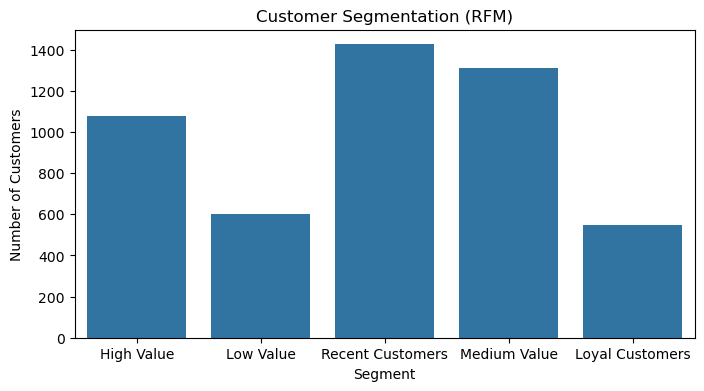

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(
    data=rfm,
    x='Customer_Segment'
)
plt.title('Customer Segmentation (RFM)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# 14. Purchase Frequency 

In [44]:
purchase_frequency = (
    df_2
    .groupby('Customer_ID', as_index=False)
    .agg(
        Total_Orders=('Order_ID', 'nunique'),
        Total_Sales=('Net_Sales', 'sum')
    )
)


In [45]:
purchase_frequency.head()


,Customer_ID,Total_Orders,Total_Sales
0,C200000,7,88485.90
1,C200001,2,22325.69
2,C200002,6,69725.42
3,C200003,6,76260.04
4,C200004,2,25977.73


In [46]:
purchase_frequency['Total_Orders'].describe()



count    4971.000000
mean        5.029169
std         2.203106
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        15.000000
Name: Total_Orders, dtype: float64

In [47]:
purchase_frequency['Purchase_Category'] = pd.cut(
    purchase_frequency['Total_Orders'],
    bins=[0, 1, 3, 5, purchase_frequency['Total_Orders'].max()],
    labels=['One-Time', 'Low Repeat (2–3)', 'Medium Repeat (4–5)', 'High Repeat (6+)']
)


In [48]:
purchase_frequency['Purchase_Category'].value_counts()


Purchase_Category
High Repeat (6+)       1920
Medium Repeat (4–5)    1760
Low Repeat (2–3)       1122
One-Time                169
Name: count, dtype: int64

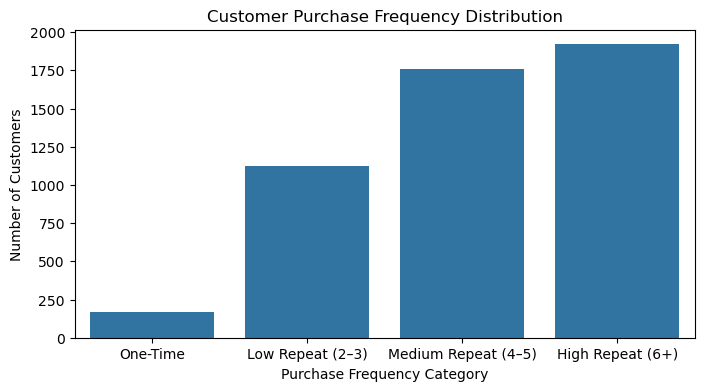

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.countplot(
    data=purchase_frequency,
    x='Purchase_Category'
)
plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Purchase Frequency Category')
plt.ylabel('Number of Customers')
plt.show()


In [ ]:
# 15. AOV Distribution 

In [50]:
order_aov = (
    df_2
    .groupby('Order_ID', as_index=False)
    .agg(
        Order_Value=('Net_Sales', 'sum')
    )
)


In [51]:
order_aov.head()


,Order_ID,Order_Value
0,O500000,911.14
1,O500001,4881.75
2,O500002,21134.14
3,O500003,20676.20
4,O500004,10313.41


In [52]:
order_aov['Order_Value'].describe()


count    25000.000000
mean     10869.198122
std       8541.194713
min         64.860000
25%       4013.755000
50%       8599.300000
75%      16055.320000
max      39934.550000
Name: Order_Value, dtype: float64

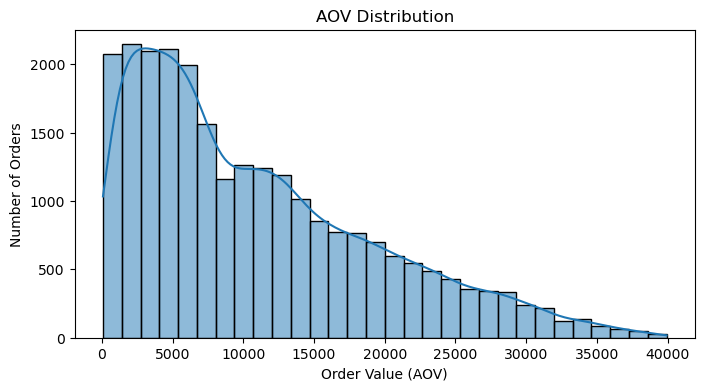

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(
    order_aov['Order_Value'],
    bins=30,
    kde=True
)
plt.title('AOV Distribution')
plt.xlabel('Order Value (AOV)')
plt.ylabel('Number of Orders')
plt.show()


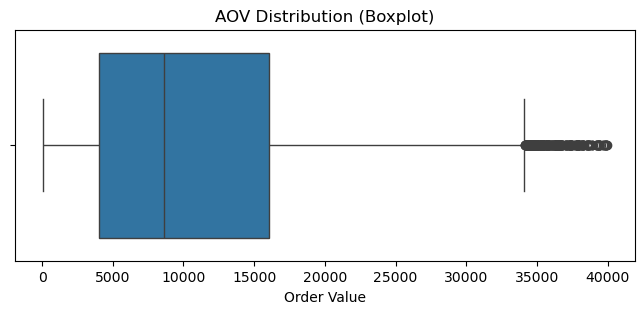

In [54]:
plt.figure(figsize=(8,3))
sns.boxplot(
    x=order_aov['Order_Value']
)
plt.title('AOV Distribution (Boxplot)')
plt.xlabel('Order Value')
plt.show()


In [ ]:
# 16. Discount Impact 

In [55]:
df_2['Discount_Flag'] = np.where(
    df_2['Discount_%'] > 0,
    'Discounted',
    'No Discount'
)


In [56]:
df_2['Discount_Flag'].value_counts()


Discount_Flag
Discounted     19925
No Discount     5075
Name: count, dtype: int64

In [57]:
discount_impact = (
    df_2
    .groupby('Discount_Flag', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
)


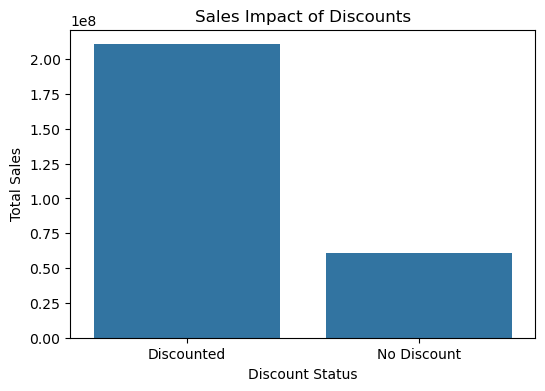

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=discount_impact,
    x='Discount_Flag',
    y='Total_Sales'
)
plt.title('Sales Impact of Discounts')
plt.xlabel('Discount Status')
plt.ylabel('Total Sales')
plt.show()


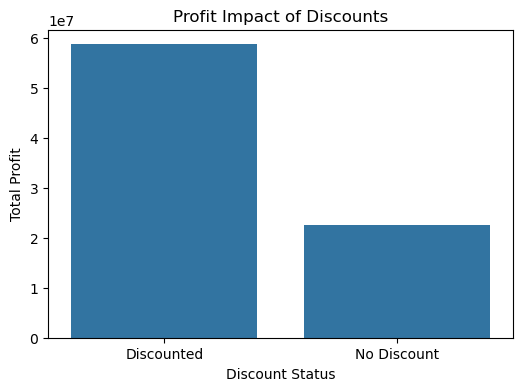

In [59]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=discount_impact,
    x='Discount_Flag',
    y='Total_Profit'
)
plt.title('Profit Impact of Discounts')
plt.xlabel('Discount Status')
plt.ylabel('Total Profit')
plt.show()


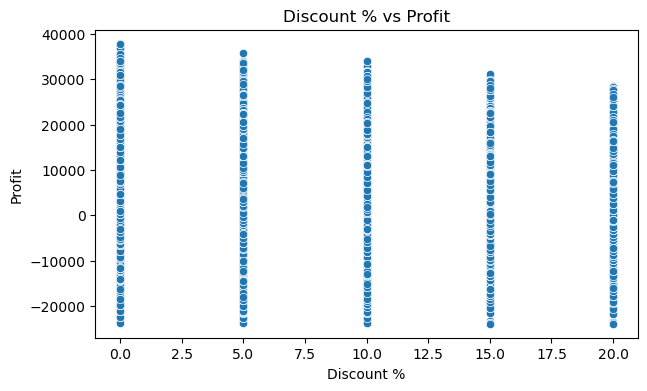

In [60]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=df_2,
    x='Discount_%',
    y='Profit'
)
plt.title('Discount % vs Profit')
plt.xlabel('Discount %')
plt.ylabel('Profit')
plt.show()


In [ ]:
# 17. Return Rates 

In [61]:
total_orders = df_2['Order_ID'].nunique()
returned_orders = df_4['Order_ID'].nunique()

overall_return_rate = (returned_orders / total_orders) * 100
overall_return_rate


6.1080000000000005

In [62]:
df_returns_flag = df_2.merge(
    df_4[['Order_ID']],
    on='Order_ID',
    how='left',
    indicator=True
)

df_returns_flag['Return_Flag'] = np.where(
    df_returns_flag['_merge'] == 'both',
    'Returned',
    'Not Returned'
)



In [63]:
df_returns_flag['Return_Flag'].value_counts()


Return_Flag
Not Returned    23473
Returned         1527
Name: count, dtype: int64

In [64]:
return_rate_product = (
    df_returns_flag
    .groupby('Product_ID', as_index=False)
    .agg(
        Total_Orders=('Order_ID', 'nunique'),
        Returned_Orders=('Return_Flag', lambda x: (x == 'Returned').sum())
    )
)


In [65]:
return_rate_product['Return_Rate_%'] = (
    return_rate_product['Returned_Orders'] /
    return_rate_product['Total_Orders']
) * 100


In [67]:
return_rate_product.sort_values('Return_Rate_%', ascending=False).head(10)


,Product_ID,Total_Orders,Returned_Orders,Return_Rate_%
56,P100056,27,7,25.925926
638,P100638,29,6,20.689655
786,P100786,29,6,20.689655
287,P100287,30,6,20.000000
207,P100207,30,6,20.000000
214,P100214,27,5,18.518519
779,P100779,29,5,17.241379
776,P100776,30,5,16.666667
384,P100384,36,6,16.666667
713,P100713,18,3,16.666667


In [68]:
df_returns_category = df_returns_flag.merge(
    df_3[['Product_ID', 'Category']],
    on='Product_ID',
    how='left'
)


In [69]:
return_rate_category = (
    df_returns_category
    .groupby('Category', as_index=False)
    .agg(
        Total_Orders=('Order_ID', 'nunique'),
        Returned_Orders=('Return_Flag', lambda x: (x == 'Returned').sum())
    )
)


In [70]:
return_rate_category['Return_Rate_%'] = (
    return_rate_category['Returned_Orders'] /
    return_rate_category['Total_Orders']
) * 100

return_rate_category


,Category,Total_Orders,Returned_Orders,Return_Rate_%
0,Beauty,4232,250,5.907372
1,Electronics,4498,281,6.247221
2,Fashion,3987,270,6.772009
3,Grocery,4742,277,5.841417
4,Home & Kitchen,3715,234,6.298789
5,Sports,3826,215,5.619446


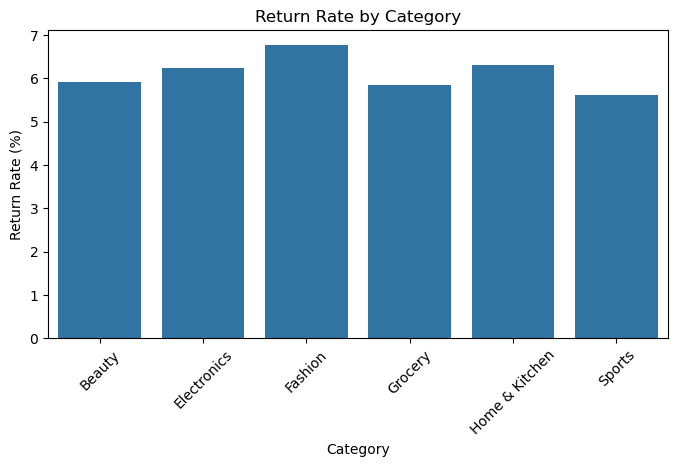

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.barplot(
    data=return_rate_category,
    x='Category',
    y='Return_Rate_%'
)
plt.title('Return Rate by Category')
plt.xlabel('Category')
plt.ylabel('Return Rate (%)')
plt.xticks(rotation=45)
plt.show()


In [ ]:
# 18. Promo vs Non-Promo 

In [72]:
df_2['Promo_Flag'] = np.where(
    df_2['Discount_%'] > 0,
    'Promo',
    'Non-Promo'
)


In [73]:
df_2['Promo_Flag'].value_counts()


Promo_Flag
Promo        19925
Non-Promo     5075
Name: count, dtype: int64

In [74]:
promo_perf = (
    df_2
    .groupby('Promo_Flag', as_index=False)
    .agg(
        Total_Sales=('Net_Sales', 'sum'),
        Total_Profit=('Profit', 'sum'),
        Orders=('Order_ID', 'nunique'),
        Units_Sold=('Quantity', 'sum')
    )
)


In [75]:
promo_perf


,Promo_Flag,Total_Sales,Total_Profit,Orders,Units_Sold
0,Non-Promo,6.104736e+07,22612120.66,5075,15218
1,Promo,2.106826e+08,58785735.61,19925,59776


In [76]:
promo_perf['AOV'] = promo_perf['Total_Sales'] / promo_perf['Orders']
promo_perf


,Promo_Flag,Total_Sales,Total_Profit,Orders,Units_Sold,AOV
0,Non-Promo,6.104736e+07,22612120.66,5075,15218,12029.037137
1,Promo,2.106826e+08,58785735.61,19925,59776,10573.781158


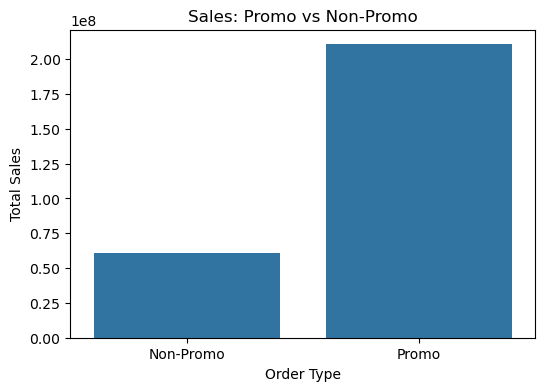

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.barplot(
    data=promo_perf,
    x='Promo_Flag',
    y='Total_Sales'
)
plt.title('Sales: Promo vs Non-Promo')
plt.xlabel('Order Type')
plt.ylabel('Total Sales')
plt.show()


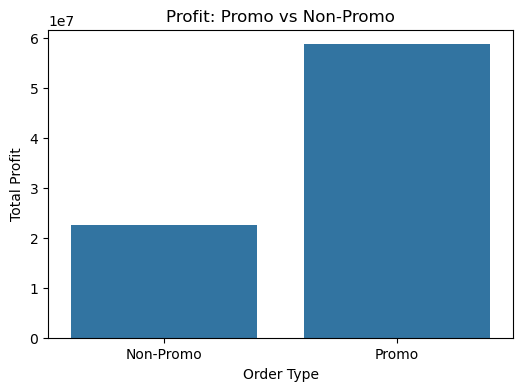

In [78]:
plt.figure(figsize=(6,4))
sns.barplot(
    data=promo_perf,
    x='Promo_Flag',
    y='Total_Profit'
)
plt.title('Profit: Promo vs Non-Promo')
plt.xlabel('Order Type')
plt.ylabel('Total Profit')
plt.show()


In [ ]:
# 19. Correlation Matrix 


In [79]:
corr_data = df_2[[
    'Net_Sales',
    'Profit',
    'Quantity',
    'Discount_%',
    'Discount_Amount'
]]


In [80]:
corr_data.head()


,Net_Sales,Profit,Quantity,Discount_%,Discount_Amount
0,81.07,-1699.96,1,0,0.0
1,110.25,-3723.39,1,0,0.0
2,114.56,-2818.43,1,0,0.0
3,123.61,-2913.46,1,0,0.0
4,140.70,-3216.95,1,0,0.0


In [81]:
correlation_matrix = corr_data.corr()
correlation_matrix


,Net_Sales,Profit,Quantity,Discount_%,Discount_Amount
Net_Sales,1.000000,0.751340,0.599595,-0.099225,0.556958
Profit,0.751340,1.000000,0.181412,-0.100670,0.390470
Quantity,0.599595,0.181412,1.000000,-0.000322,0.398144
Discount_%,-0.099225,-0.100670,-0.000322,1.000000,0.594589
Discount_Amount,0.556958,0.390470,0.398144,0.594589,1.000000


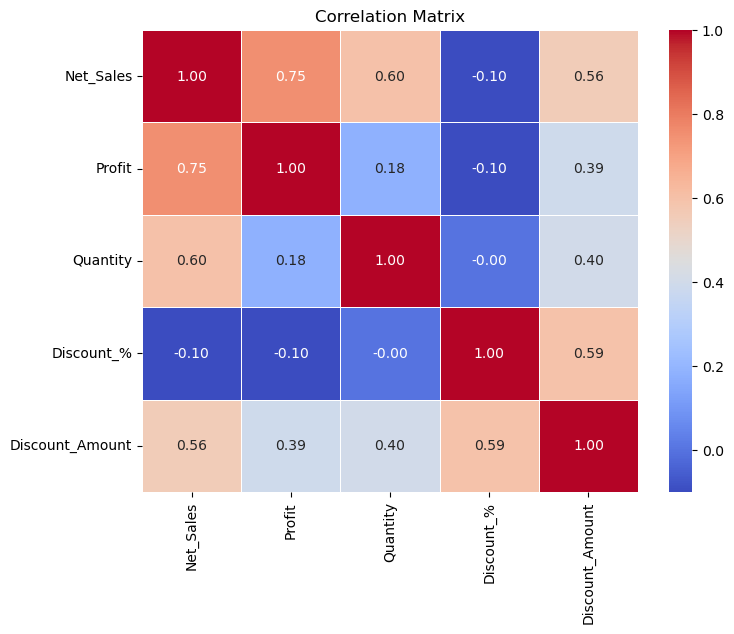

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# 20. Anomaly Detection

In [84]:
df_2['Order_Date'] = pd.to_datetime(df_2['Order_Date'])

daily_sales = (
    df_2
    .assign(Date=df_2['Order_Date'].dt.date)
    .groupby('Date', as_index=False)
    .agg(Daily_Sales=('Net_Sales', 'sum'))
)


In [85]:
daily_sales.head()


,Date,Daily_Sales
0,2024-01-01,333074.66
1,2024-01-02,488445.49
2,2024-01-03,365302.01
3,2024-01-04,299227.36
4,2024-01-05,330132.12


In [86]:
mean_sales = daily_sales['Daily_Sales'].mean()
std_sales = daily_sales['Daily_Sales'].std()


In [87]:
daily_sales['Z_Score'] = (
    (daily_sales['Daily_Sales'] - mean_sales) / std_sales
)


In [88]:
daily_sales['Anomaly_Flag'] = np.where(
    daily_sales['Z_Score'].abs() > 3,
    'Anomaly',
    'Normal'
)


In [89]:
daily_sales['Anomaly_Flag'].value_counts()


Anomaly_Flag
Normal     729
Anomaly      2
Name: count, dtype: int64

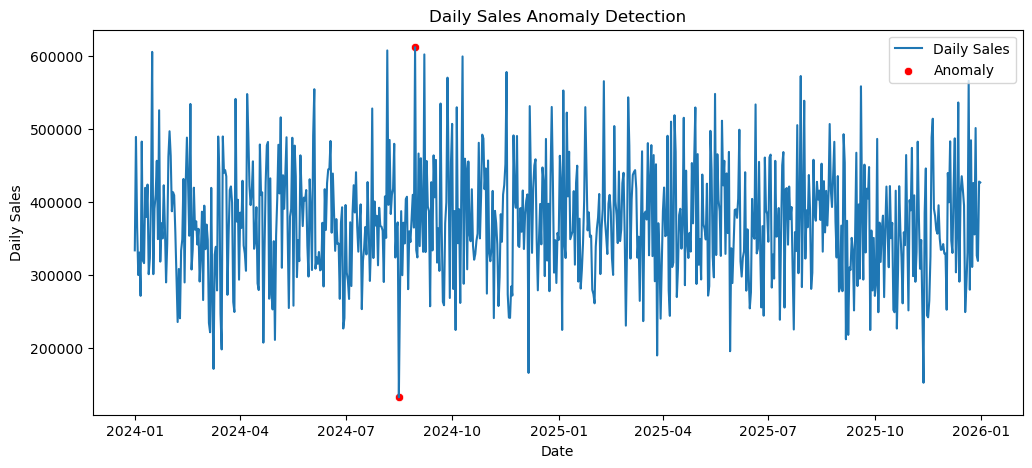

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

sns.lineplot(
    data=daily_sales,
    x='Date',
    y='Daily_Sales',
    label='Daily Sales'
)

sns.scatterplot(
    data=daily_sales[daily_sales['Anomaly_Flag'] == 'Anomaly'],
    x='Date',
    y='Daily_Sales',
    color='red',
    label='Anomaly'
)

plt.title('Daily Sales Anomaly Detection')
plt.xlabel('Date')
plt.ylabel('Daily Sales')
plt.legend()
plt.show()


In [91]:
daily_sales[daily_sales['Anomaly_Flag'] == 'Anomaly']


,Date,Daily_Sales,Z_Score,Anomaly_Flag
228,2024-08-16,131893.75,-3.030838,Anomaly
242,2024-08-30,611344.03,3.028191,Anomaly


# 10. Business Insights

Sales exhibit strong seasonal spikes, indicating demand concentration in specific periods and the need for proactive inventory and workforce planning.

A small group of top-performing products drives the majority of total revenue, following the Pareto (80/20) principle.

Several regions show consistent revenue and growth decline, highlighting localized operational or market challenges.

Customers acquired through promotions have higher churn and lower repeat purchase rates compared to non-promotional customers.

Heavy discounting improves short-term sales but negatively impacts long-term customer value and profitability.

# 11. Recommendations

Increase inventory for top-performing SKUs
Ensure adequate stock levels for high-demand and high-revenue products to prevent stockouts and maximize sales opportunities.

Reduce discounts on low-margin products
Re-evaluate promotional strategies for products with thin margins to protect profitability and avoid unnecessary revenue leakage.

Improve product quality for high-return items
Focus on quality improvements for products with high return rates to enhance customer satisfaction and reduce reverse logistics costs.

Target high-value customers
Prioritize retention and personalized marketing for high-LTV and repeat customers using segmentation insights (e.g., RFM analysis).

Allocate marketing budget to strong-performing regions and stores
Shift investments toward regions and stores with consistent growth and higher margins to optimize ROI.

# 12. PPT Structure 

# 1. Overview

- Project objective and business problem
- Scope of analysis (sales, products, customers, regions)
- Key stakeholders & expected impact

# 2. Data Summary

- Data sources (Orders, Products, Customers, Stores, Returns)
- Time period covered
- Total records & key fields
- Data preparation overview

# 3. Key KPIs

- Total Sales / GMV
- Margin %
- Units Sold
- Average Order Value (AOV)
- Repeat Purchase Rate
- Return Rate
- YoY / MoM Growth

# 4. Sales Trends

- Monthly revenue trend
- Seasonal patterns
- YoY & MoM growth insights
- Peak vs low-performing periods

# 5. Product Performance

- Top 10 & Bottom 10 SKUs
- Category-wise revenue & margin
- High-margin vs high-volume products
- Product contribution to total sales

# 6. Store / Region Performance

- Store-wise sales comparison
- Region heatmap
- Best & worst performing locations
- Regional growth/decline insights

# 7. Customer Analysis

- New vs Returning customers
- RFM segmentation
- Purchase frequency distribution
- High-value customer contribution

# 8. Promotions Analysis

- Promo vs Non-promo sales
- Discount impact on margin
- Customer behavior during promotions
- Promo-driven churn insights

# 9. Returns Analysis

- Overall return rate
- Products with highest returns
- Return impact on revenue & margin
- Quality or logistics signals

# 10. Key Findings

- Top products drive majority of revenue
- Promotions increase volume but reduce margins
- Certain regions underperform consistently
- High-value customers generate disproportionate revenue

# 11. Recommendations

- Increase stock for top SKUs
- Reduce discounts on low-margin products
- Improve quality for high-return items
- Focus retention on high-value customers
- Allocate budget to strong regions

# 12. Conclusion / Business Impact

- Summary of insights
- Value delivered to business
- How decisions can improve revenue, margin, and retention
- Next steps / future enhancements